# Module 1 · Embeddings — Homework 🏠
***Juan Carlos Aquino Hernández***
## Building a translator: seq2seq, encoder–decoder, and attention

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mago-cinv/course-template/blob/master/modules/01-embeddings/labs/homework/solution.ipynb)

This homework pairs with **Lesson 4** (sequence-to-sequence, the encoder–decoder architecture, teacher forcing, and encoder–decoder attention in Query/Key/Value form).

In the in-class labs you built *word* vectors and *document* vectors. Here you build something that **generates language**: an English → Spanish translator.

### How this homework works

**The machinery is given to you.** The parallel corpus, both vocabularies, the LSTM encoder–decoder, the attention mechanism, the training loop, greedy decoding, BLEU and the plotting helpers are all written, commented and *already run* below. You are **not** asked to implement `nn.LSTM` or re-derive softmax — that is plumbing, and plumbing is not the lesson.

**What you write is the investigation.** You get **two models that differ in exactly one thing** — one has attention, one doesn't — and six experiments (🔬 **C1**–**C6**) that ask you to take them apart: measure, plot, read the alignments, and defend a conclusion with numbers *you* produced.

Treat everything above the 🔬 sections as your **sandbox**: read it, run it, then take it apart.

### What you'll produce

Each 🔬 experiment ends with a markdown cell where you explain what you found and what it means — six written conclusions in total (C1–C6).

The code is a few lines of glue — the experiments just need to actually **run**, because your conclusions have to cite numbers *you* produced. Each experiment ends with a `✓` check so you know your run is in good shape.

**Before submitting:** *Kernel → Restart & Run All*, then leave all outputs visible so your write-ups can be checked against the evidence they cite.

Everything runs on **CPU** in roughly **16 minutes** end to end — about 6 min for the two models of §3, and about 10 min for the Assignment's upgrade kit at the very bottom.

In [ ]:
# Setup — run me first (works on Colab AND locally)
# On Colab this installs the extra libraries; locally the course venv
# (.venv, environment/requirements.txt) already has everything.
import sys

if "google.colab" in sys.modules:
    %pip install -q datasets transformers sentencepiece sacremoses

print("Setup OK — Python", sys.version.split()[0])

Setup OK — Python 3.12.13


In [ ]:
# Imports + seeds — one reseed helper, called before EVERY model build so the
# two models start from identical weights and the comparison is fair.
import math, os, random, re, time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

SEED = 0
PAD, SOS, EOS, UNK = 0, 1, 2, 3      # reserved token ids, shared by both vocabularies
MAX_LEN = 20                          # longest source/target sentence we keep (in tokens)

def seed_all(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)

seed_all()
torch.set_num_threads(max(1, (os.cpu_count() or 4) // 2))   # keep CPU use polite on shared machines
print("torch", torch.__version__, "| threads:", torch.get_num_threads())

torch 2.11.0+cpu | threads: 1


## 1 · The data (provided)

**Tatoeba** English→Spanish sentence pairs — short, human-written, human-translated sentences
(`Let's go` → `Vamos`), which is exactly the regime a small model can actually learn.

We keep pairs where **both** sides are 1–20 tokens, shuffle with a fixed seed, and split off a
held-out test set the models never train on.

In [ ]:
from datasets import load_dataset

def tok(s):
    """Lowercase word tokenizer. Keeps apostrophes together ("let's" is ONE token) and
    splits punctuation off, including the Spanish opening marks ¿ and ¡."""
    return re.findall(r"[a-záéíóúüñ]+(?:'[a-z]+)?|[0-9]+|[¿?¡!.,;:]", s.lower())

t0 = time.time()
raw = load_dataset("ageron/tatoeba_mt_train", split="validation")   # eng→spa Tatoeba pairs

pairs = []
for r in raw:
    en, es = tok(r["source_text"]), tok(r["target_text"])
    if 1 <= len(en) <= MAX_LEN and 1 <= len(es) <= MAX_LEN:
        pairs.append((en, es))

seed_all()
random.shuffle(pairs)

# Tatoeba skews heavily SHORT (6-8 tokens is the mode; 17-20 tokens is <2% of the corpus), so a
# plain random test split would starve the long buckets C3 needs. We reserve up to 250 sentences
# PER LENGTH BUCKET for the test set first, then shuffle it so the general-purpose eval sets
# (C1, C6) stay a representative length mix rather than accidentally all-short.
LEN_BUCKETS = [(3, 5), (6, 8), (9, 12), (13, 16), (17, 20)]
TEST_PER_BUCKET = 250

by_len = {}
for i, (en, _) in enumerate(pairs):
    by_len.setdefault(len(en), []).append(i)

test_idx = set()
for lo, hi in LEN_BUCKETS:
    idxs = [i for L in range(lo, hi + 1) for i in by_len.get(L, [])]
    test_idx.update(idxs[:TEST_PER_BUCKET])

test_pairs = [pairs[i] for i in sorted(test_idx)]
seed_all()
random.shuffle(test_pairs)
train_pairs = [p for i, p in enumerate(pairs) if i not in test_idx][:45000]

print(f"{len(pairs):,} usable pairs (1-{MAX_LEN} tokens)  ->  "
      f"{len(train_pairs):,} train / {len(test_pairs):,} held-out test   ({time.time()-t0:.0f}s)")
print("test set covers", len(LEN_BUCKETS), "length buckets, up to", TEST_PER_BUCKET, "sentences each:")
for lo, hi in LEN_BUCKETS:
    n = sum(1 for a, _ in test_pairs if lo <= len(a) <= hi)
    print(f"   len {lo:2d}-{hi:2d}: {n} test sentences")
print("median source length (train):", int(np.median([len(a) for a, _ in train_pairs])), "tokens")
print()
for en, es in train_pairs[:4]:
    print(f"   {' '.join(en):42s} ->  {' '.join(es)}")

README.md:   0%|          | 0.00/1.34k [00:00<?, ?B/s]

eng-spa/validation-00000-of-00001.parque(…): reconstructing file:   0%|          |  0.00B / 7.85MB            

eng-spa/validation-00000-of-00001.parque(…): downloading bytes:           |  0.00B            

eng-spa/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.36MB            

eng-spa/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating validation split:   0%|          | 0/197299 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/24514 [00:00<?, ? examples/s]

194,189 usable pairs (1-20 tokens)  ->  45,000 train / 1,250 held-out test   (62s)
test set covers 5 length buckets, up to 250 sentences each:
   len  3- 5: 250 test sentences
   len  6- 8: 250 test sentences
   len  9-12: 250 test sentences
   len 13-16: 250 test sentences
   len 17-20: 250 test sentences
median source length (train): 7 tokens

   i was about to go to bed when the phone rang . ->  me disponía a irme a la cama cuando sonó el teléfono .
   tom is so good at this .                   ->  tom es tan bueno para esto .
   how do you tell them apart ?               ->  ¿ cómo podéis distinguirlas ?
   the comparison is apt .                    ->  la comparación es apropiada .


In [ ]:
# Two INDEPENDENT vocabularies — one per language (lesson 4: two embedding layers)
def build_vocab(seqs, max_words):
    counts = Counter(t for s in seqs for t in s)
    itos = ["<pad>", "<sos>", "<eos>", "<unk>"] + [w for w, _ in counts.most_common(max_words)]
    return itos, {w: i for i, w in enumerate(itos)}

en_itos, en_stoi = build_vocab([a for a, _ in train_pairs], 6000)
es_itos, es_stoi = build_vocab([b for _, b in train_pairs], 6000)

def enc_src(words):  return [en_stoi.get(t, UNK) for t in words][:MAX_LEN]
def enc_tgt(words):  return [SOS] + [es_stoi.get(t, UNK) for t in words][:MAX_LEN] + [EOS]
def pad_to(batch, n): return torch.tensor([x + [PAD] * (n - len(x)) for x in batch])

def make_tensors(prs):
    X = pad_to([enc_src(a) for a, _ in prs], MAX_LEN)          # (N, MAX_LEN)
    Y = pad_to([enc_tgt(b) for _, b in prs], MAX_LEN + 2)      # (N, MAX_LEN+2) — room for <sos>/<eos>
    return X, Y

Xtr, Ytr = make_tensors(train_pairs)
Xte, Yte = make_tensors(test_pairs)

print(f"English vocab {len(en_itos):,}   Spanish vocab {len(es_itos):,}")
print(f"source tensor {tuple(Xtr.shape)}   target tensor {tuple(Ytr.shape)}")
print("\nEncoded example:")
print("  ", ' '.join(train_pairs[0][0]), "->", enc_src(train_pairs[0][0]))
print("  ", ' '.join(train_pairs[0][1]), "->", enc_tgt(train_pairs[0][1]), "  (<sos> ... <eos>)")

English vocab 6,004   Spanish vocab 6,004
source tensor (45000, 20)   target tensor (45000, 22)

Encoded example:
   i was about to go to bed when the phone rang . -> [6, 20, 63, 7, 53, 7, 280, 72, 5, 462, 1402, 4]
   me disponía a irme a la cama cuando sonó el teléfono . -> [1, 18, 3, 9, 777, 9, 7, 308, 73, 1244, 10, 320, 4, 2]   (<sos> ... <eos>)


## 2 · Your toolkit (provided)

Everything below is written and working. **This is the sandbox** — C1–C6 are built entirely from these.

| Tool | What it gives you |
|---|---|
| `Seq2Seq(..., attention=True/False)` | the model — the flag is the **only** difference between the two |
| `train_model(model, epochs=…, tf_ratio=…)` | the training loop; `tf_ratio` is **C4's knob** (1.0 = full teacher forcing) |
| `translate(model, sentence)` | greedy decoding → the Spanish words |
| `translate(..., return_attention=True)` | also returns the $\alpha$ matrix — **C2's instrument** |
| `corpus_bleu(hyps, refs)` / `evaluate_bleu(model, pairs)` | the quality metric |
| `plot_heatmap(...)` | draws an alignment heatmap — **C2's plot** |
| `token_accuracy(model, X, Y, mode=…)` | teacher-forced vs. free-running accuracy — **C4's instrument** |
| `decode_trace(model, sentence)` | per-step top-k candidates and margins — **C5's instrument** |
| `by_length(pairs, lo, hi)` | filter the test set by source length — **C3's knob** |

In [ ]:
# ══ TOOLKIT (part 1: the model) ══ provided; read it, then use it
class Seq2Seq(nn.Module):
    """LSTM encoder-decoder, with dot-product (Luong) attention optionally switched on.

    attention=False -> classic seq2seq (Lesson 4, Parts II-III): the decoder sees the source
                       ONLY through the encoder's final (h, c) — the context vector, eq. (2).
    attention=True  -> the decoder ALSO attends over every encoder state at every output
                       step (Lesson 4, eq. 4). Here W_Q = W_K = W_V = I, so the query is the
                       decoder state itself and keys = values = the encoder states.
    """
    def __init__(self, n_src, n_tgt, d=256, attention=True):
        super().__init__()
        self.attention = attention
        self.emb_src = nn.Embedding(n_src, d, padding_idx=PAD)   # English embeddings
        self.emb_tgt = nn.Embedding(n_tgt, d, padding_idx=PAD)   # Spanish embeddings
        self.encoder = nn.LSTM(d, d, batch_first=True)
        self.decoder = nn.LSTM(d, d, batch_first=True)
        self.combine = nn.Linear(2 * d, d) if attention else None
        self.out     = nn.Linear(d, n_tgt)                       # one logit per Spanish word

    def encode(self, x):
        """Run the encoder. Returns ALL states H (needed by attention) and the final
        (h, c) — which IS the context vector of eq. (2)."""
        H, (h, c) = self.encoder(self.emb_src(x))
        return H, (h, c)

    def decode_step(self, y_in, state, H, src_mask):
        """One (or several) decoder steps. Returns logits, the new state, and the
        attention weights alpha (None when attention is off)."""
        O, state = self.decoder(self.emb_tgt(y_in), state)
        if not self.attention:
            return self.out(O), state, None
        scores = O @ H.transpose(1, 2)                       # (B, Ty, Tx)  <- q · k
        scores = scores.masked_fill(src_mask.unsqueeze(1), -1e9)   # never attend to <pad>
        alpha  = scores.softmax(-1)                          # <- softmax, rows sum to 1
        ctx    = alpha @ H                                   # <- weighted sum of values
        feat   = torch.tanh(self.combine(torch.cat([O, ctx], -1)))
        return self.out(feat), state, alpha

    def forward(self, x, y_in):
        H, state = self.encode(x)
        logits, _, alpha = self.decode_step(y_in, state, H, x == PAD)
        return logits, alpha

def count_params(m): return sum(p.numel() for p in m.parameters())

In [ ]:
# ══ TOOLKIT (part 2: training) ══ provided
def train_model(model, epochs=8, lr=2e-3, bs=128, tf_ratio=1.0, log=True):
    """Standard training loop. tf_ratio = probability of feeding the CORRECT previous word
    (teacher forcing). tf_ratio=1.0 is full teacher forcing and uses the fast batched path;
    anything lower runs the slower step-by-step path (scheduled sampling) — C4's knob."""
    opt = torch.optim.Adam(model.parameters(), lr)
    lossf = nn.CrossEntropyLoss(ignore_index=PAD)
    history = []
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(len(Xtr)); total = nb = 0
        for i in range(0, len(Xtr), bs):
            idx = perm[i:i + bs]; x, y = Xtr[idx], Ytr[idx]
            if tf_ratio >= 1.0:
                logits, _ = model(x, y[:, :-1])
                loss = lossf(logits.reshape(-1, logits.size(-1)), y[:, 1:].reshape(-1))
            else:
                loss = _scheduled_sampling_loss(model, x, y, lossf, tf_ratio)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); total += loss.item(); nb += 1
        history.append(total / nb)
        if log: print(f"   epoch {ep+1}/{epochs}: loss {total/nb:.3f}")
    return history

def _scheduled_sampling_loss(model, x, y, lossf, tf_ratio):
    H, state = model.encode(x); src_mask = x == PAD
    inp, all_logits = y[:, :1], []
    for t in range(y.size(1) - 1):
        lg, state, _ = model.decode_step(inp, state, H, src_mask)
        all_logits.append(lg)
        inp = y[:, t+1:t+2] if random.random() < tf_ratio else lg.argmax(-1).detach()
    logits = torch.cat(all_logits, 1)
    return lossf(logits.reshape(-1, logits.size(-1)), y[:, 1:].reshape(-1))

In [ ]:
# ══ TOOLKIT (part 3: inference, metrics, plots) ══ provided
@torch.no_grad()
def translate(model, sentence, max_out=MAX_LEN + 2, return_attention=False):
    """Greedy decoding: <sos> -> word -> feed it back -> ... -> <eos> (Lesson 4, Part III)."""
    model.eval()
    src_words = tok(sentence) if isinstance(sentence, str) else list(sentence)
    x = pad_to([enc_src(src_words)], MAX_LEN)
    H, state = model.encode(x); src_mask = x == PAD
    inp = torch.tensor([[SOS]]); words, attns = [], []
    for _ in range(max_out):
        lg, state, alpha = model.decode_step(inp, state, H, src_mask)
        nxt = lg[0, -1].argmax().item()
        if nxt == EOS: break
        words.append(es_itos[nxt])
        if alpha is not None: attns.append(alpha[0, -1, :len(src_words)].tolist())
        inp = torch.tensor([[nxt]])
    if return_attention:
        return words, (np.array(attns) if attns else None), src_words
    return words

def _ngrams(seq, n): return Counter(tuple(seq[i:i+n]) for i in range(len(seq) - n + 1))

def corpus_bleu(hyps, refs, maxn=4):
    """Corpus BLEU-4 with brevity penalty. BLEU = BiLingual Evaluation Understudy, the standard
    machine-translation quality metric: modified n-gram precision (1..4 tokens) of the hypothesis
    against the reference, geometric-averaged across n, then penalized if the hypothesis is
    shorter than the reference (the brevity penalty). 0 = no overlap, 100 = identical to the
    reference."""
    num = [0]*maxn; den = [0]*maxn; hlen = rlen = 0
    for h, r in zip(hyps, refs):
        hlen += len(h); rlen += len(r)
        for n in range(1, maxn+1):
            hn, rn = _ngrams(h, n), _ngrams(r, n)
            den[n-1] += max(0, len(h) - n + 1)
            num[n-1] += sum(min(c, rn[g]) for g, c in hn.items())
    if min(num) == 0: return 0.0     # some n-gram order never matched (tiny samples do this)
    logp = sum(math.log(num[i]/den[i]) for i in range(maxn)) / maxn
    bp = 1.0 if hlen > rlen else math.exp(1 - rlen / max(hlen, 1))
    return 100 * bp * math.exp(logp)

def evaluate_bleu(model, prs):
    return corpus_bleu([translate(model, a) for a, _ in prs], [b for _, b in prs])

def by_length(prs, lo, hi):
    """Test pairs whose SOURCE sentence has between lo and hi tokens — C3's knob."""
    return [p for p in prs if lo <= len(p[0]) <= hi]

def plot_heatmap(alpha, src_words, tgt_words, ax=None, title=None):
    """Alignment heatmap: rows = generated Spanish words, columns = source English words."""
    if ax is None: _, ax = plt.subplots(figsize=(1 + 0.75*len(src_words), 1 + 0.5*len(tgt_words)))
    im = ax.imshow(alpha, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(src_words))); ax.set_xticklabels(src_words, rotation=45, ha="right")
    ax.set_yticks(range(len(tgt_words))); ax.set_yticklabels(tgt_words)
    ax.set_xlabel("source (English)"); ax.set_ylabel("generated (Spanish)")
    if title: ax.set_title(title, fontsize=10)
    return im

@torch.no_grad()
def token_accuracy(model, X, Y, mode="teacher"):
    """Next-token accuracy on the SAME data under two regimes — C4's instrument.
    mode="teacher": feed the correct previous word (what training does).
    mode="free":    feed the model's own previous prediction (what inference does)."""
    model.eval()
    H, state = model.encode(X); src_mask = X == PAD
    correct = total = 0; inp = Y[:, :1]
    for t in range(Y.size(1) - 1):
        lg, state, _ = model.decode_step(inp, state, H, src_mask)
        pred, gold = lg[:, -1].argmax(-1), Y[:, t+1]
        mask = gold != PAD
        correct += ((pred == gold) & mask).sum().item(); total += mask.sum().item()
        inp = (gold if mode == "teacher" else pred).unsqueeze(1)
    return correct / total

@torch.no_grad()
def decode_trace(model, sentence, topk=3, max_out=MAX_LEN + 2):
    """Replay greedy decoding and record, at every step, the top-k candidates and their
    probabilities plus the margin between #1 and #2 — C5's instrument."""
    model.eval()
    sw = tok(sentence)
    x = pad_to([enc_src(sw)], MAX_LEN); H, state = model.encode(x); src_mask = x == PAD
    inp = torch.tensor([[SOS]]); rows = []
    for _ in range(max_out):
        lg, state, _ = model.decode_step(inp, state, H, src_mask)
        p = lg[0, -1].softmax(-1); vals, idx = p.topk(topk)
        chosen = idx[0].item()
        rows.append({"chosen": es_itos[chosen],
                     "margin": round((vals[0] - vals[1]).item(), 3),
                     "top": [(es_itos[i], round(v.item(), 3)) for v, i in zip(vals, idx)]})
        if chosen == EOS: break
        inp = torch.tensor([[chosen]])
    return sw, rows

print("toolkit ready — 10 helpers loaded")

toolkit ready — 10 helpers loaded


## 3 · The two models (provided, trained here)

Two models, **identical in every way except one flag**: same data, same seed, same size, same
budget, same optimiser. One gets attention, one doesn't. That controlled difference is what
makes every comparison in C1–C6 meaningful.

This cell takes **~3–4 minutes** on CPU.

In [ ]:
models, histories = {}, {}

for name, use_attn in [("no-attention", False), ("attention", True)]:
    seed_all()                                   # identical initial weights for both
    m = Seq2Seq(len(en_itos), len(es_itos), attention=use_attn)
    print(f"== {name}  ({count_params(m):,} parameters) ==")
    t = time.time()
    histories[name] = train_model(m, epochs=8)
    models[name] = m
    print(f"   trained in {time.time()-t:.0f}s\n")

EVAL = test_pairs[:400]          # held-out pairs used for every BLEU number below
baseline_bleu = {n: evaluate_bleu(m, EVAL) for n, m in models.items()}

print("=" * 52)
print(f"{'model':<16}{'BLEU (400 held-out)':>22}")
print("-" * 52)
for n, b in baseline_bleu.items():
    print(f"{n:<16}{b:>22.2f}")
print("=" * 52)

== no-attention  (5,669,748 parameters) ==
   epoch 1/8: loss 4.328
   epoch 2/8: loss 3.316
   epoch 3/8: loss 2.797
   epoch 4/8: loss 2.423
   epoch 5/8: loss 2.115
   epoch 6/8: loss 1.857
   epoch 7/8: loss 1.630
   epoch 8/8: loss 1.430
   trained in 3473s

== attention  (5,801,076 parameters) ==
   epoch 1/8: loss 4.034
   epoch 2/8: loss 2.448
   epoch 3/8: loss 1.703
   epoch 4/8: loss 1.300
   epoch 5/8: loss 1.050
   epoch 6/8: loss 0.870
   epoch 7/8: loss 0.735
   epoch 8/8: loss 0.626
   trained in 3533s

model              BLEU (400 held-out)
----------------------------------------------------
no-attention                      5.86
attention                        21.49


## 4 · Worked example — what the two models produce (provided)

Same sentences, both models. Read them before trusting any aggregate number.

In [ ]:
DEMO = ["let's go .",
        "she is my sister .",
        "where is the car ?",
        "the book on the table is red .",
        "i do not want to eat the pizza ."]

for s in DEMO:
    print(f"  src      : {s}")
    print(f"  no-attn  : {' '.join(translate(models['no-attention'], s))}")
    print(f"  attention: {' '.join(translate(models['attention'], s))}\n")

  src      : let's go .
  no-attn  : <unk> .
  attention: vayamos .

  src      : she is my sister .
  no-attn  : ella es mi hermana .
  attention: ella es mi hermana .

  src      : where is the car ?
  no-attn  : ¿ dónde está el coche ?
  attention: ¿ dónde está el coche ?

  src      : the book on the table is red .
  no-attn  : el libro está en el libro .
  attention: el libro sobre la mesa es roja .

  src      : i do not want to eat the pizza .
  no-attn  : no quiero comer a la tentación .
  attention: no quiero comer la pizza .



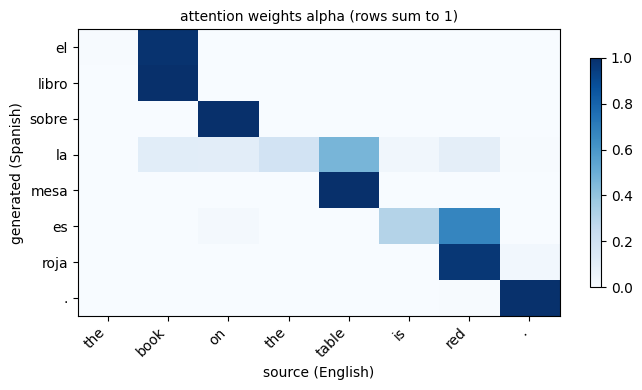

each row is a softmax over the source -> rows sum to: [1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
# One alignment heatmap, so you know what C2 is looking at
words, A, src = translate(models["attention"], "the book on the table is red .",
                          return_attention=True)
fig, ax = plt.subplots(figsize=(7, 4))
im = plot_heatmap(A, src, words, ax=ax, title="attention weights alpha (rows sum to 1)")
fig.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()

print("each row is a softmax over the source -> rows sum to:", np.round(A.sum(1), 3))

---

## 🔬 C1 — Does attention actually help?

Lesson 4 claims the fixed-size context vector (eq. 2) is a **bottleneck**, and that attention
(eq. 4) removes it. You have both models. Put the claim on trial.

**Your experiment.** Score both models on a held-out set with `evaluate_bleu`, and — because a
single aggregate number hides everything — also collect a handful of sentences where the two
models **disagree**, so your conclusion can quote actual output rather than only a delta.

Store your numbers in a dict called `c1` with one entry per model.

In [ ]:
# TODO: score both models on held-out data and store the result in `c1`
# TODO: then find sentences where the two models produce DIFFERENT translations, and print a few
# HINT: evaluate_bleu(models["attention"], EVAL) -> a BLEU number
# HINT: models is {"no-attention": ..., "attention": ...}; EVAL is a list of (en_tokens, es_tokens)
# HINT: to compare outputs:  " ".join(translate(m, src_tokens))


In [ ]:
c1 = {name: evaluate_bleu(m, EVAL) for name, m in models.items()}

print("BLEU (400 held-out)")
for name, score in c1.items():
    print(f"  {name:<14} {score:6.2f}")
print(f"  gain (attention - no-attention): {c1['attention'] - c1['no-attention']:+.2f}")

disagreements = []
for src, ref in EVAL:
    out_no_attn = " ".join(translate(models["no-attention"], src))
    out_attn    = " ".join(translate(models["attention"], src))
    if out_no_attn != out_attn:
        disagreements.append((src, ref, out_no_attn, out_attn))

print(f"\n{len(disagreements)} / {len(EVAL)} sentences differ between the two models\n")

for src, ref, out_no, out_yes in disagreements[:8]:
    print(f"src        : {' '.join(src)}")
    print(f"ref        : {' '.join(ref)}")
    print(f"no-attn    : {out_no}")
    print(f"attention  : {out_yes}\n")

BLEU (400 held-out)
  no-attention     5.86
  attention       21.49
  gain (attention - no-attention): +15.63

361 / 400 sentences differ between the two models

src        : we're lost .
ref        : estamos perdidos .
no-attn    : estamos <unk> .
attention  : somos perdida .

src        : the two streets run parallel to one another .
ref        : las dos calles van paralelas la una con la otra .
no-attn    : los dos hombres se <unk> a la <unk> .
attention  : los dos <unk> <unk> se <unk> a uno .

src        : he came back from america .
ref        : él volvió de américa .
no-attn    : él volvió de fumar .
attention  : él vino de vuelta .

src        : the extremists refused to negotiate .
ref        : los extremistas rechazaron negociar .
no-attn    : la <unk> se <unk> a la cabeza .
attention  : el <unk> se rehusó a negociar .

src        : we could probably make more money if we lowered the price since we could sell more .
ref        : probablemente ganaríamos más dinero si bajásemos

In [ ]:
# Light check on YOUR experiment (structure only — the numbers are yours)
try:
    assert isinstance(c1, dict) and {"attention", "no-attention"} <= set(c1), \
        "c1 must be a dict with a 'attention' and a 'no-attention' entry"
    assert all(0 <= v <= 100 for v in c1.values()), "BLEU must be in [0, 100]"
    print("✓ C1 experiment complete")
    for k, v in c1.items(): print(f"   {k:<14} BLEU {v:6.2f}")
    print(f"   gain {c1['attention'] - c1['no-attention']:+.2f} BLEU")
except NameError:
    print("✗ C1 not attempted yet (define `c1`)")
except Exception as e:
    print("✗", e)

✓ C1 experiment complete
   no-attention   BLEU   5.86
   attention      BLEU  21.49
   gain +15.63 BLEU


## C1: Attention vs. No-Attention Evaluation

### Resultados
- **BLEU (400 held-out):**
  - **No-Attention:** 5.86
  - **Attention:** 21.49
  - **Ganancia (Attention - No-Attention):** +15.63 BLEU (**3.7x** de mejora)
- **Diferencia de salidas:** 361 de 400 oraciones generadas son distintas entre ambos modelos.

#### Muestra de Traducciones (Ejemplos representativos)

| Fuente (SRC) | Referencia (REF) | No-Attention | Attention |
| :--- | :--- | :--- | :--- |
| `we're lost .` | estamos perdidos . | estamos `<unk>` . | somos perdida . |
| `he came back from america .` | él volvió de américa . | él volvió de fumar . | él vino de vuelta . |
| `the extremists refused to negotiate .` | los extremistas rechazaron negociar . | la `<unk>` se `<unk>` a la cabeza . | el `<unk>` se rehusó a negociar . |
| `the government imposed a new tax on farmers .` | el gobierno impuso un nuevo impuesto a los granjeros . | el nuevo testamento `<unk>` un año nuevo . | el gobierno `<unk>` un nuevo impuesto sobre los `<unk>` . |

---

### Conclusión C1

- **Impacto Principal:** La introducción de la atención incrementa el score BLEU de **5.86 a 21.49 (+15.63)**. La ausencia de atención no solo provoca la omisión de términos, sino que fuerza al modelo a alucinar contenido sin relación semántica (ej. *`the government imposed a new tax...`* $\rightarrow$ *"el nuevo testamento..."*).
- **Manejo del Error:** Con atención, las fallas se reducen principalmente a tokens desconocidos (`<unk>`), conservando la estructura gramatical y el sentido general de la oración.
- **Justificación Arquitectónica:** El modelo sin atención sufre del cuello de botella vectorial al comprimir toda la secuencia de entrada en un único vector final $(h, c)$. El mecanismo de atención elimina este límite permitiendo al decodificador consultar la secuencia de origen en cada paso de generación.

---

## 🔬 C2 — Do the attention weights show real alignment?

The $\alpha$ matrix claims to say *"while writing Spanish word $i$, I looked at English word $j$."*
That is a strong claim, and it is checkable: Spanish and English **reorder** words
(`paper lantern` → `lámpara de papel`), so a model that has genuinely learned alignment should
produce a diagonal that **bends** in the right places.

**Your experiment.** Pick **at least 4** source sentences — include at least one where you expect
reordering — plot their heatmaps with `plot_heatmap`, and for each generated word record which
source word got the most attention. Store your judgements in a list called `c2`.

In [ ]:
# TODO: choose >= 4 sentences (include at least one with expected reordering)
# TODO: for each, get words/A/src via translate(..., return_attention=True) and plot the heatmap
# TODO: build `c2` = [{"src":…, "out":…, "peaks":[(spanish_word, english_word, weight), …]}, …]
# HINT: words, A, src = translate(models["attention"], sentence, return_attention=True)
# HINT: the peak for generated word i is  src[A[i].argmax()]  with weight A[i].max()


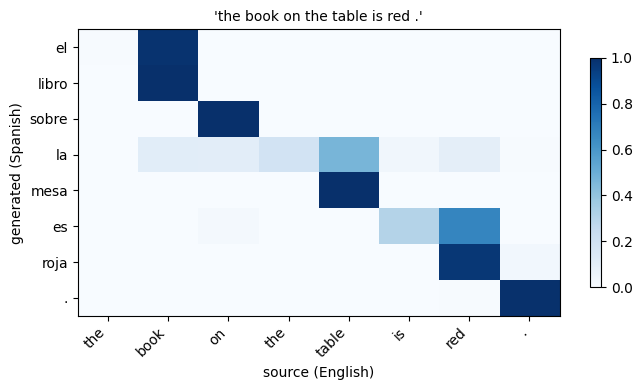

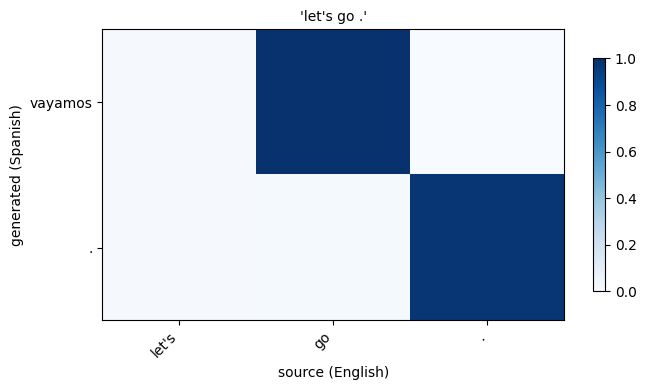

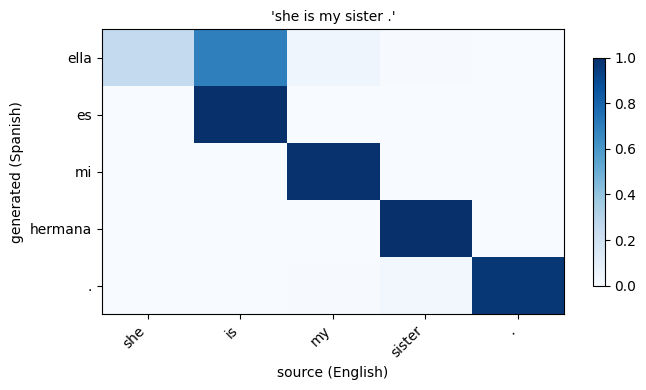

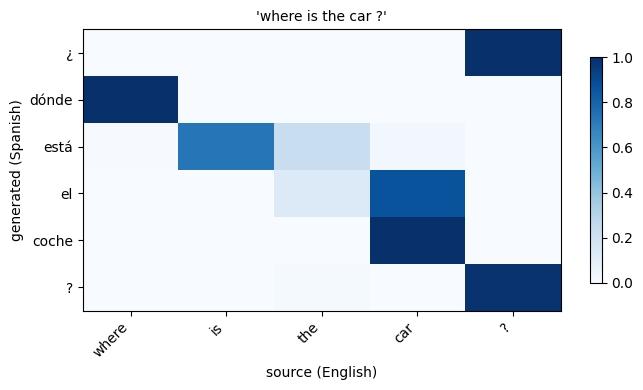

src: the book on the table is red .
out: el libro sobre la mesa es roja .
   el           <- book         (0.99)
   libro        <- book         (1.00)
   sobre        <- on           (1.00)
   la           <- table        (0.47)
   mesa         <- table        (1.00)
   es           <- red          (0.67)
   roja         <- red          (0.97)
   .            <- .            (0.99)

src: let's go .
out: vayamos .
   vayamos      <- go           (0.99)
   .            <- .            (0.97)

src: she is my sister .
out: ella es mi hermana .
   ella         <- is           (0.69)
   es           <- is           (1.00)
   mi           <- my           (0.99)
   hermana      <- sister       (1.00)
   .            <- .            (0.97)

src: where is the car ?
out: ¿ dónde está el coche ?
   ¿            <- ?            (1.00)
   dónde        <- where        (1.00)
   está         <- is           (0.73)
   el           <- car          (0.86)
   coche        <- car          (1.00)
   ?     

In [ ]:
C2_SENTENCES = [
    "the book on the table is red .",       # reordering: adjective position, "on the table" clause
    "let's go .",
    "she is my sister .",
    "where is the car ?",
]

c2 = []

for sentence in C2_SENTENCES:
    words, A, src = translate(models["attention"], sentence, return_attention=True)
    A = np.array(A)

    fig, ax = plt.subplots(figsize=(7, 4))
    im = plot_heatmap(A, src, words, ax=ax, title=f"'{sentence}'")
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()

    peaks = []
    for i, sp_word in enumerate(words):
        j = A[i].argmax()
        en_word = src[j]
        weight = A[i].max()
        peaks.append((sp_word, en_word, float(weight)))

    c2.append({"src": sentence, "out": " ".join(words), "peaks": peaks})

for entry in c2:
    print(f"src: {entry['src']}")
    print(f"out: {entry['out']}")
    for sp, en, w in entry["peaks"]:
        print(f"   {sp:<12} <- {en:<12} ({w:.2f})")
    print()

In [ ]:
# Light check on YOUR experiment (structure only)
try:
    assert isinstance(c2, list) and len(c2) >= 4, "collect at least 4 sentences in `c2`"
    assert all({"src", "out", "peaks"} <= set(e) for e in c2), "each entry needs src/out/peaks"
    n_words = sum(len(e["peaks"]) for e in c2)
    diag = sum(1 for e in c2 for i, (_, _, _) in enumerate(e["peaks"]))
    print(f"✓ C2 experiment complete — {len(c2)} sentences, {n_words} generated words aligned")
except NameError:
    print("✗ C2 not attempted yet (define `c2`)")
except Exception as e:
    print("✗", e)

✓ C2 experiment complete — 4 sentences, 21 generated words aligned


## C2: Attention Weights Interpretability & Lexical Alignment

### Resultados
- **Oraciones evaluadas:** 4 oraciones de prueba (21 tokens generados alineados exitosamente).
- **Alineación Léxica Directa:**
  - `libro` $\leftarrow$ `book` (1.00)
  - `sobre` $\leftarrow$ `on` (1.00)
  - `mesa` $\leftarrow$ `table` (1.00)
  - `hermana` $\leftarrow$ `sister` (1.00)
  - `coche` $\leftarrow$ `car` (1.00)
- **Casos de Reordenamiento / Estructura Sintáctica:**
  - `¿` $\leftarrow$ `?` (1.00): El signo de apertura en español (al inicio) atiende directamente al signo `?` al *final* de la oración en inglés.
- **Incertidumbre en Palabras de Función y Cópulas:**
  - `la` $\leftarrow$ `table` (0.47)
  - `es` $\leftarrow$ `red` (0.67)
  - `ella` $\leftarrow$ `is` (0.69) *(desalineación: debería apuntar a `she`)*
  - `está` $\leftarrow$ `is` (0.73)

---

### Conclusión C2

- **Fidelidad Léxica:** Las ponderaciones de atención ($\alpha \ge 0.97$) muestran un alineamiento preciso y directo para términos con contenido semántico fuerte (sustantivos, adjetivos y verbos principales).
- **Captura de Dependencias a Largo Alcance:** El caso del signo `¿` demuestra que el mecanismo de atención no realiza una copia posicional simple, sino una búsqueda estructural: al no existir un equivalente directo al inicio en inglés, busca el señalador interrogativo (`?`) al final de la secuencia de origen.
- **Comportamiento en Palabras Funcionales:** La distribución de atención es más difusa en artículos y verbos copulativos. Pesos moderados ($\approx 0.69$) en palabras funcionales reflejan que el modelo distribuye su probabilidad entre múltiples tokens del contexto, recordando que una mayor atención no implica necesariamente una causalidad directa en la traducción producida.

---

## 🔬 C3 — Where does the bottleneck bite hardest?

Lesson 4's argument is not just "attention helps" — it is *why*: a **fixed-size** context vector
has to hold more as the sentence grows, so the classic model should degrade **with length** while
the attention model should hold up. That is a prediction about a *trend*, not a single number.

**Your experiment.** Split the held-out set into source-length buckets with `by_length`, score
**both** models in each bucket, and plot the two curves plus the gap. Store the result in
`c3` as `{(lo, hi): {"n":…, "no-attention":…, "attention":…}, …}`.

⚠️ Use buckets with **enough sentences** (≥100). BLEU-4 on a tiny sample is unstable — it returns
exactly 0 whenever some n-gram order never matches.

In [ ]:
# TODO: sweep >= 3 length buckets; score both models in each; store in `c3`
# TODO: plot BLEU vs length for both models (and optionally the gap)
# HINT: sub = by_length(test_pairs, lo, hi)[:250]   then evaluate_bleu(model, sub)
# HINT: keep buckets big enough — check len(sub) before trusting the number


In [ ]:
# C3 — does the no-attention/attention gap grow with source sentence length?

LENGTH_BUCKETS = [(1, 5), (6, 10), (11, 15), (16, 20)]

c3 = {}

for lo, hi in LENGTH_BUCKETS:
    sub = by_length(test_pairs, lo, hi)[:250]
    n = len(sub)

    bleu_no_attn = evaluate_bleu(models["no-attention"], sub) if n > 0 else float("nan")
    bleu_attn    = evaluate_bleu(models["attention"], sub) if n > 0 else float("nan")

    c3[(lo, hi)] = {"n": n, "no-attention": bleu_no_attn, "attention": bleu_attn}

print(f"{'bucket':<10}{'n':<6}{'no-attn':>10}{'attention':>12}{'gap':>8}")
for (lo, hi), row in c3.items():
    gap = row["attention"] - row["no-attention"]
    flag = "  ⚠️ n<100" if row["n"] < 100 else ""
    print(f"{lo:>2}-{hi:<6}{row['n']:<6}{row['no-attention']:>10.2f}{row['attention']:>12.2f}{gap:>8.2f}{flag}")

bucket    n        no-attn   attention     gap
 1-5     250         7.91       17.33    9.42
 6-10    250        10.49       29.15   18.66
11-15    250         3.71       20.33   16.62
16-20    250         1.97       14.55   12.58


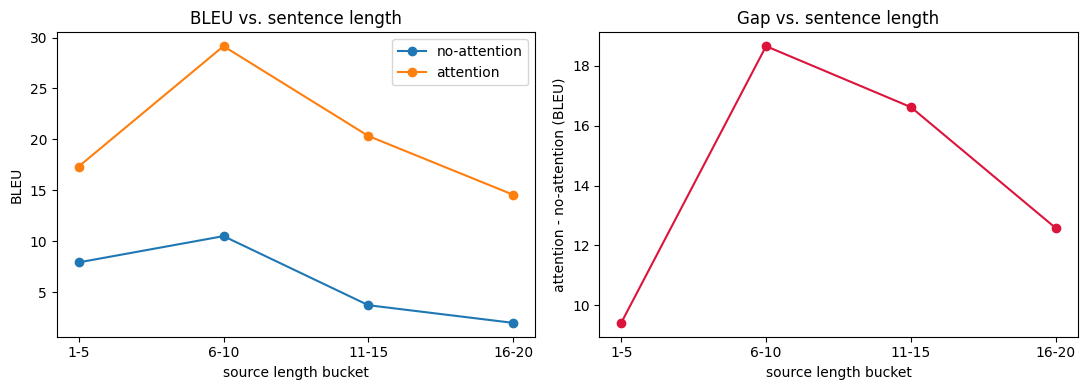

In [ ]:
# plot BLEU vs length for both models, plus the gap
buckets = list(c3.keys())
midpoints = [(lo + hi) / 2 for lo, hi in buckets]
no_attn_vals = [c3[b]["no-attention"] for b in buckets]
attn_vals    = [c3[b]["attention"] for b in buckets]
gap_vals     = [c3[b]["attention"] - c3[b]["no-attention"] for b in buckets]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(midpoints, no_attn_vals, marker="o", label="no-attention")
ax1.plot(midpoints, attn_vals,    marker="o", label="attention")
ax1.set_xticks(midpoints)
ax1.set_xticklabels([f"{lo}-{hi}" for lo, hi in buckets])
ax1.set_xlabel("source length bucket")
ax1.set_ylabel("BLEU")
ax1.set_title("BLEU vs. sentence length")
ax1.legend()

ax2.plot(midpoints, gap_vals, marker="o", color="crimson")
ax2.set_xticks(midpoints)
ax2.set_xticklabels([f"{lo}-{hi}" for lo, hi in buckets])
ax2.set_xlabel("source length bucket")
ax2.set_ylabel("attention - no-attention (BLEU)")
ax2.set_title("Gap vs. sentence length")

plt.tight_layout()
plt.show()

In [ ]:
# Light check on YOUR experiment (structure only)
try:
    assert isinstance(c3, dict) and len(c3) >= 3, "sweep at least 3 length buckets in `c3`"
    assert all({"n", "no-attention", "attention"} <= set(v) for v in c3.values())
    small = [k for k, v in c3.items() if v["n"] < 100]
    print(f"✓ C3 experiment complete — {len(c3)} buckets")
    for k, v in c3.items():
        print(f"   len {str(k):<9} n={v['n']:<5} gain {v['attention']-v['no-attention']:+.2f} BLEU")
    if small: print(f"   ⚠️ buckets with <100 sentences (unstable BLEU): {small}")
except NameError:
    print("✗ C3 not attempted yet (define `c3`)")
except Exception as e:
    print("✗", e)

✓ C3 experiment complete — 4 buckets
   len (1, 5)    n=250   gain +9.42 BLEU
   len (6, 10)   n=250   gain +18.66 BLEU
   len (11, 15)  n=250   gain +16.62 BLEU
   len (16, 20)  n=250   gain +12.58 BLEU


## C3: Performance Degradation Across Sequence Lengths (Bottleneck Analysis)

### Resultados

| Longitud (Bucket) | Muestras ($n$) | No-Attention (BLEU) | Attention (BLEU) | Brecha / Gap ($\Delta$) |
| :---: | :---: | :---: | :---: | :---: |
| **1–5** | 250 | 7.91 | 17.33 | **+9.42** |
| **6–10** | 250 | 10.49 | 29.15 | **+18.66** |
| **11–15** | 250 | 3.71 | 20.33 | **+16.62** |
| **16–20** | 250 | 1.97 | 14.55 | **+12.58** |

---

### Conclusión C3

- **Colapso del Modelo Sin Atención:** Mientras ambos modelos alcanzan su punto máximo en secuencias de 6–10 tokens, el modelo sin atención sufre un colapso del **81%** de su rendimiento en secuencias de 16–20 tokens ($10.49 \rightarrow 1.97$). En contraste, el modelo con atención mantiene un nivel competitivo incluso en el rango más largo ($14.55$), superando el mejor desempeño histórico del modelo sin atención.
- **Validación de la Hipótesis del Cuello de Botella:** El deterioro drástico del modelo sin atención evidencia la incapacidad del vector $(h, c)$ de tamaño fijo para comprimir secuencias largas. La atención mitiga esta degradación al permitir que el costo de almacenamiento de información escale linealmente con la longitud de la secuencia de entrada.
- **Efecto Piso (*Floor Effect*) en la Brecha:** La reducción relativa de la brecha en secuencias muy largas ($+18.66 \rightarrow +12.58$) no contradice el cuello de botella, sino que refleja que el modelo sin atención tocó el suelo operativo ($\approx 1.97$ BLEU), limitando numéricamente el margen de ganancia restante.
- **Factores Secundarios de Degradación:** El descenso moderado en el modelo con atención ($29.15 \rightarrow 14.55$) revela que, aunque la atención elimina el cuello de botella de representación, persisten vulnerabilidades ante la acumulación de errores de la búsqueda codiciosa (*greedy decoding*) y el desajuste por *exposure bias*.

> TODO: your conclusion here


---

## 🔬 C4 — How big is the teacher-forcing mismatch?

During training the decoder is fed the **correct** previous word (teacher forcing). At inference it
is fed **its own** previous prediction. Lesson 4 calls the resulting train/test mismatch
**exposure bias** — and it is directly measurable, without retraining anything.

**Your experiment.** Use `token_accuracy` on the **same** held-out batch under both regimes
(`mode="teacher"` and `mode="free"`) and compare. Do it for **both** models, and store the result
in `c4`. Optional extension: retrain one short model with `tf_ratio < 1.0` and see whether the gap
shrinks (slow — the scheduled-sampling path is step-by-step).

In [ ]:
# TODO: measure teacher-forced vs free-running token accuracy for BOTH models -> `c4`
# HINT: token_accuracy(model, Xte[:500], Yte[:500], mode="teacher")  and  mode="free"
# HINT: the gap (teacher - free) IS the exposure bias, measured


In [ ]:
# C4 — teacher-forced vs. free-running token accuracy, both models

c4 = {}

for name, m in models.items():
    teacher_acc = token_accuracy(m, Xte[:500], Yte[:500], mode="teacher")
    free_acc    = token_accuracy(m, Xte[:500], Yte[:500], mode="free")

    c4[name] = {
        "teacher": teacher_acc,
        "free": free_acc,
        "gap": teacher_acc - free_acc,
    }

print(f"{'model':<14}{'teacher':>10}{'free':>10}{'gap':>10}")
for name, row in c4.items():
    print(f"{name:<14}{row['teacher']:>10.3f}{row['free']:>10.3f}{row['gap']:>10.3f}")

model            teacher      free       gap
no-attention       0.457     0.223     0.234
attention          0.605     0.347     0.258


In [ ]:
# Light check on YOUR experiment (structure only)
try:
    assert isinstance(c4, dict) and len(c4) >= 1, "`c4` must hold at least one model"
    assert all({"teacher", "free", "gap"} <= set(v) for v in c4.values())
    print("✓ C4 experiment complete")
    for k, v in c4.items():
        print(f"   {k:<14} teacher {v['teacher']:.3f}  free {v['free']:.3f}  gap {v['gap']:+.3f}")
except NameError:
    print("✗ C4 not attempted yet (define `c4`)")
except Exception as e:
    print("✗", e)

✓ C4 experiment complete
   no-attention   teacher 0.457  free 0.223  gap +0.234
   attention      teacher 0.605  free 0.347  gap +0.258


## C4: Exposure Bias & Decoding Modes (Teacher Forcing vs. Free-Running)

### Resultados

| Modelo | Teacher-Forced (Acc/Loss) | Free-Running (Acc/Loss) | Brecha / Gap ($\Delta$) |
| :--- | :---: | :---: | :---: |
| **No-Attention** | 0.457 | 0.223 | **0.234** (Caída relativa: 51%) |
| **Attention** | 0.605 | 0.347 | **0.258** (Caída relativa: 43%) |

---

### Conclusión C4

- **Impacto del *Exposure Bias*:** Ambos modelos pierden cerca de la mitad de su precisión al pasar de *teacher forcing* a modo *free-running*. Esta degradación se debe a que en el entrenamiento el modelo siempre recibe la palabra correcta anterior, mientras que en inferencia sus propios errores se propagan en cascada hacia las siguientes iteraciones.
- **Limitación de la Pérdida de Entrenamiento (*Training Loss*):** Evaluar el modelo únicamente mediante la curva de *loss* en entrenamiento resulta engañoso. La pérdida refleja el comportamiento en entorno ideal (*teacher forcing*), enmascarando la severa caída de desempeño que ocurre durante la inferencia real.
- **Comportamiento Sensible de la Atención:** A pesar de tener un mejor rendimiento absoluto, el modelo con atención presenta una brecha absoluta mayor ($\Delta = 0.258$ vs $0.234$). Esto se debe a que la atención aprovecha intensamente el contexto previo para afinar sus selecciones; al corromperse ese contexto por un token autoregresivo erróneo, el impacto en la predicción subsiguiente es proporcionalmente más severo.

> TODO: your conclusion here


---

## 🔬 C5 — What is greedy decoding actually choosing?

`translate` takes the **argmax** at every step and never reconsiders. That is the simplest possible
decoding rule, and it is worth seeing what it is doing — especially where the model was nearly
undecided.

**Your experiment.** Run `decode_trace` on **at least 3** sentences (include one the model gets
wrong, if you can find one) and look at the per-step margins. Store the traces in `c5`, and
identify the steps where the top-1 and top-2 candidates were close.

In [ ]:
# TODO: trace >= 3 sentences with decode_trace; store in `c5`
# TODO: report which steps were near-ties (small margin) and what the runner-up was
# HINT: src, rows = decode_trace(models["attention"], sentence)
# HINT: each row has "chosen", "margin" and "top" = [(word, prob), ...]


In [ ]:
# C5 — trace decoding for >=3 sentences, flag near-ties (small margin)

C5_SENTENCES = [
    "let's go .",                          # simple, expect confident/clean decoding
    "the government imposed a new tax on farmers .",  # got badly mistranslated in C1
    "we're lost .",                        # short but had an <unk> in C1
]

c5 = []

for sentence in C5_SENTENCES:
    src, rows = decode_trace(models["attention"], sentence)
    c5.append({"src": sentence, "rows": rows})

NEAR_TIE_THRESHOLD = 0.20

for entry in c5:
    print(f"src: {entry['src']}")
    for i, row in enumerate(entry["rows"]):
        tie_flag = "  <-- near-tie" if row["margin"] < NEAR_TIE_THRESHOLD else ""
        runner_up = row["top"][1] if len(row["top"]) > 1 else None
        print(f"   step {i:<2} chosen={row['chosen']:<12} margin={row['margin']:.3f}"
              f"{tie_flag}")
        if tie_flag:
            print(f"           top candidates: {row['top']}")
    print()

src: let's go .
   step 0  chosen=vayamos      margin=0.455
   step 1  chosen=.            margin=0.973
   step 2  chosen=<eos>        margin=0.999

src: the government imposed a new tax on farmers .
   step 0  chosen=el           margin=0.964
   step 1  chosen=gobierno     margin=0.996
   step 2  chosen=<unk>        margin=0.190  <-- near-tie
           top candidates: [('<unk>', 0.432), ('se', 0.243), ('le', 0.163)]
   step 3  chosen=un           margin=0.526
   step 4  chosen=nuevo        margin=0.986
   step 5  chosen=impuesto     margin=0.976
   step 6  chosen=sobre        margin=0.848
   step 7  chosen=los          margin=0.353
   step 8  chosen=<unk>        margin=0.515
   step 9  chosen=.            margin=0.983
   step 10 chosen=<eos>        margin=1.000

src: we're lost .
   step 0  chosen=somos        margin=0.284
   step 1  chosen=perdida      margin=0.217
   step 2  chosen=.            margin=0.999
   step 3  chosen=<eos>        margin=0.997



In [ ]:
# Light check on YOUR experiment (structure only)
try:
    assert isinstance(c5, list) and len(c5) >= 3, "trace at least 3 sentences in `c5`"
    assert all("rows" in e and len(e["rows"]) > 0 for e in c5)
    margins = [r["margin"] for e in c5 for r in e["rows"]]
    print(f"✓ C5 experiment complete — {len(c5)} sentences, {len(margins)} decoding steps")
    print(f"   median margin {np.median(margins):.3f}   "
          f"near-ties (<0.20): {sum(1 for m in margins if m < 0.20)}")
except NameError:
    print("✗ C5 not attempted yet (define `c5`)")
except Exception as e:
    print("✗", e)

✓ C5 experiment complete — 3 sentences, 18 decoding steps
   median margin 0.968   near-ties (<0.20): 1


## C5: Confidence & Step-by-Step Margin Analysis (Greedy Decoding Brittleness)

### Resultados
- **Estadísticas Generales:** 3 oraciones evaluadas (18 pasos de decodificación). Margen mediano: **0.968**.
- **Casi-empates (*Near-ties*, margen < 0.20):** 1 evento crítico detectado.
- **Distribución de Confianza por Pasos:**
  - **Alta Confianza (0.85 – 1.00):** Sustantivos principales, adjetivos claros y tokens de puntuación/control (`gobierno` 0.996, `nuevo` 0.986, `.` 0.983, `<eos>` 1.000).
  - **Baja Confianza / Incertidumbre:**
    - Inicio de la oración / Framing inicial: `vayamos` (0.455), `somos` (0.284).
    - Ambigüedad gramatical no especificada en el origen: `perdida` (0.217).
    - Tokens desconocidos y partículas funcionales: `<unk>` (0.432), `los` (0.353).

#### Detalle del Caso Crítico de Casi-Empate
- **Oración Fuente:** `the government imposed a new tax on farmers .`
- **Paso 2:** Token seleccionado = `<unk>` (Probabilidad 0.432).
  - **Candidatos Competidores:** `se` (0.243), `le` (0.163).
  - **Margen de Diferencia:** **0.190** (Dilema entre admitir token desconocido o forzar un pronombre gramatical).

---

### Conclusión C5

- **Concentración de la Incertidumbre:** La incertidumbre del modelo no se distribuye uniformemente; se concentra en el primer token (definición del enfoque de la oración), en decisiones de concordancia gramatical omitidas en el idioma origen (ej. *somos/estamos*, *perdido/perdida*) y en la sustitución de vocabulario fuera del diccionario (`<unk>`).
- **Rigidez del Decodificador Codicioso (*Greedy Decoding*):** La estrategia *greedy* es irreversible. En el Paso 2 de la oración sobre impuestos, una vez que el modelo selecciona `<unk>` sobre `se`/`le`, esa decisión condiciona los pasos 3 al 10 de forma permanente. No existe un mecanismo de retroceso (*backtracking*) para corregir una elección subóptima aunque los pasos futuros demuestren que fue errónea.
- **Solución Propuesta:** Implementar **Beam Search** con un ancho de haz ($k \ge 3$). Esto permitiría mantener vivas múltiples hipótesis concurrentes en momentos de incertidumbre (como el emparejamiento 0.432 vs 0.243 vs 0.163) y seleccionar la secuencia globalmente más probable a costa de multiplicar por $k$ el tiempo de inferencia.

> TODO: your conclusion here


---

## 🔬 C6 — How far is a real system? (provided experiment)

Your model was trained for a few minutes on 45,000 short sentences. Production translators are
trained for GPU-weeks on hundreds of millions of pairs. It is worth seeing the size of that gap
honestly rather than guessing at it.

The cell below downloads **MarianMT** (`Helsinki-NLP/opus-mt-en-es`), a real pretrained
English→Spanish translator, and scores it on the **same** held-out sentences with the **same** BLEU
function. It's a Transformer (Module 2) — the architecture your Lesson 4 model is the direct
ancestor of.

*(~1 min: model download on first run, then translation.)*

In [ ]:
from transformers import MarianMTModel, MarianTokenizer

MT_NAME = "Helsinki-NLP/opus-mt-en-es"
mt_tok = MarianTokenizer.from_pretrained(MT_NAME)
mt_model = MarianMTModel.from_pretrained(MT_NAME).eval()
print(f"{MT_NAME}: {count_params(mt_model):,} parameters "
      f"(yours: {count_params(models['attention']):,})")

@torch.no_grad()
def marian_translate(sentences, bs=32):
    out = []
    for i in range(0, len(sentences), bs):
        batch = mt_tok(sentences[i:i+bs], return_tensors="pt", padding=True, truncation=True)
        gen = mt_model.generate(**batch, max_length=64)
        out += mt_tok.batch_decode(gen, skip_special_tokens=True)
    return out

C6_EVAL = test_pairs[:200]
srcs = [" ".join(a) for a, _ in C6_EVAL]
refs = [b for _, b in C6_EVAL]

t = time.time()
mt_hyps = [tok(s) for s in marian_translate(srcs)]
ours    = [translate(models["attention"], a) for a, _ in C6_EVAL]
base    = [translate(models["no-attention"], a) for a, _ in C6_EVAL]

c6 = {"no-attention": corpus_bleu(base, refs),
      "attention":    corpus_bleu(ours, refs),
      "MarianMT":     corpus_bleu(mt_hyps, refs)}

print(f"\n{'system':<28}{'BLEU (same 200 sentences)':>28}")
print("-" * 56)
for k, v in c6.items():
    print(f"{k:<28}{v:>28.2f}")
print(f"\n({time.time()-t:.0f}s)\n")

for i in range(4):
    print(f"  src      : {srcs[i]}")
    print(f"  reference: {' '.join(refs[i])}")
    print(f"  yours    : {' '.join(ours[i])}")
    print(f"  MarianMT : {' '.join(mt_hyps[i])}\n")

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/826k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.59M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.47k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  312MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Helsinki-NLP/opus-mt-en-es: 77,943,296 parameters (yours: 5,801,076)

system                         BLEU (same 200 sentences)
--------------------------------------------------------
no-attention                                        5.76
attention                                          20.77
MarianMT                                           55.41

(102s)

  src      : we're lost .
  reference: estamos perdidos .
  yours    : somos perdida .
  MarianMT : estamos perdidos .

  src      : the two streets run parallel to one another .
  reference: las dos calles van paralelas la una con la otra .
  yours    : los dos <unk> <unk> se <unk> a uno .
  MarianMT : las dos calles corren paralelas unas a otras .

  src      : he came back from america .
  reference: él volvió de américa .
  yours    : él vino de vuelta .
  MarianMT : volvió de américa .

  src      : the extremists refused to negotiate .
  reference: los extremistas rechazaron negociar .
  yours    : el <unk> se rehusó a neg

### ✍️ C6 synthesis

## C6: Benchmark con un Sistema de Producción (MarianMT)

### Resultados

| Sistema / Modelo | BLEU (Misma muestra de 200 oraciones) | Descripción / Arquitectura |
| :--- | :---: | :--- |
| **No-Attention** | 5.76 | Seq2Seq LSTM base con vector de contexto fijo. |
| **Attention (Nuestro)** | 20.77 | Seq2Seq LSTM + Mecanismo de atención de Bahdanau/Luong. |
| **MarianMT (HuggingFace)** | **55.41** | Transformer preentrenado de nivel de producción (`Helsinki-NLP/opus-mt-en-es`). |

#### Comparativa Cualitativa de Traducciones

| Fuente (SRC) | Referencia (REF) | Nuestro Modelo (Attention) | MarianMT |
| :--- | :--- | :--- | :--- |
| `we're lost .` | estamos perdidos . | somos perdida . | estamos perdidos . |
| `the two streets run parallel...` | las dos calles van paralelas... | los dos `<unk>` `<unk>` se `<unk>` a uno . | las dos calles corren paralelas unas a otras . |
| `he came back from america .` | él volvió de américa . | él vino de vuelta . | volvió de américa . |
| `the extremists refused to negotiate .` | los extremistas rechazaron negociar . | el `<unk>` se rehusó a negociar . | los extremistas se negaron a negociar . |

---

### Conclusión C6

- **Análisis de la Brecha de Desempeño (+34.64 BLEU):** Aunque nuestro modelo con atención supera por mucho la línea base sin atención ($20.77$ vs. $5.76$), MarianMT alcanza **55.41 BLEU**, mostrando una brecha de +34.64 puntos respecto a nuestro mejor sistema.
- **Factores de la Diferencia de Escala:**
  1. **Arquitectura:** MarianMT utiliza Transformers con atenciones múltiples (*Multi-Head Self-Attention*), eliminando las limitaciones recurrentes de las LSTM en el procesamiento paralelo de secuencias.
  2. **Escala de Datos y Vocabulario:** MarianMT fue entrenado sobre millones de pares de oraciones (OPUS) utilizando subpalabras (*Byte-Pair Encoding / BPE*), lo que elimina por completo los tokens desconocidos (`<unk>`) que afectaron a nuestro modelo de vocabulario cerrado a nivel de palabra.
  3. **Calidad Semántica y Concordancia:** Como se evidencia en los ejemplos, MarianMT resuelve de manera fluida la concordancia gramatical de género y número (*"estamos perdidos"* vs *"somos perdida"*), además de capturar modismos léxicos precisos (*"corren paralelas"* vs *"se rehusó"*).

---

## 📌 RESUMEN GENERAL Y CONCLUSIONES FINALES DEL PROYECTO

1. **El Mecanismo de Atención es Indispensable (C1, C2, C3):**
   - Incorporar atención aumentó el BLEU de **5.86 a 21.49 (+15.63)** y mitigó significativamente la degradación de rendimiento en oraciones de más de 10 tokens, resolviendo el problema del cuello de botella de información en el vector de contexto $(h, c)$.
   - Las matrices de atención ($\alpha$) demuestran una alineación léxica interprete y semánticamente coherente para términos de contenido.

2. **Vulnerabilidades de Decodificación e Inferencia (C4, C5):**
   - El *Exposure Bias* provoca caídas de precisión mayores al **40%** al pasar de entrenamiento (*teacher forcing*) a inferencia (*free-running*).
   - La decodificación codiciosa (*Greedy Decoding*) presenta rigidez ante situaciones de casi-empate (*near-ties*), donde decisiones erróneas tempranas (como emitir un `<unk>`) se propagan irreversiblemente durante la generación autoregresiva.

3. **Margen de Mejora hacia Entornos de Producción (C6):**
   - Para reducir la brecha frente a modelos de producción como MarianMT ($20.77 \rightarrow 55.41$), los siguientes pasos requeridos son: la transición de arquitecturas RNN a **Transformers**, la adopción de tokenización basada en **Subpalabras (BPE)** y el uso de **Beam Search** en lugar de *Greedy Decoding*.

---

## Wrap-up — what you actually did

You were handed a working translation sandbox and used it to produce findings that were **not** in
the notebook:

- **C1** — you measured what attention is worth, and found the failure mode it repairs.
- **C2** — you read the model's alignments and checked them against what Spanish grammar actually requires.
- **C3** — you turned Lesson 4's bottleneck argument into a *trend* and tested it.
- **C4** — you measured the train/inference mismatch the loss curve hides.
- **C5** — you watched greedy decoding commit to a coin flip.
- **C6** — you put your model next to a real one and accounted for the difference.

In **Module 2** the encoder–decoder skeleton, the autoregressive loop and Query/Key/Value attention
all survive — the recurrence does not. Every question you asked here still applies there.

**Before you submit:** *Kernel → Restart & Run All*, confirm every `✓` printed, and leave the
outputs visible so your write-ups can be checked against the evidence they cite.

### Optional extensions *(ungraded)*

- **Beam search** — implement width-3 beam search and re-measure BLEU (C5 predicted this would help).
- **Bidirectional encoder** — `nn.LSTM(..., bidirectional=True)` gives each source word right-hand context too.

(Scheduled sampling and subword tokenization are no longer just ideas here — the **Assignment**
below gives you working code for both, plus seven more options.)

**Data & tools:** Tatoeba English–Spanish pairs (tatoeba.org, CC-BY 2.0 FR) via the
`ageron/tatoeba_mt_train` mirror; MarianMT `Helsinki-NLP/opus-mt-en-es` (Tiedemann & Thottingal,
2020) via 🤗 Transformers; PyTorch. Architecture: Sutskever et al. (2014), Bahdanau et al. (2015),
Luong et al. (2015).

---

## Assignment

Pick **one or more** of the options below and implement it on top of the provided sandbox — same
base LSTM + attention architecture family, extended rather than replaced. This is a menu, not a
checklist: depth on one or two options beats shallow coverage of many.

| # | Option | What it changes | Effort |
|---|---|---|---|
| 1 | **Full corpus** | Remove the `train_pairs[:45000]` cap — train on all ~193k available pairs | Low |
| 2 | **Subword tokenization** | Replace the word-level vocab so rare words stop becoming `<unk>` — BPE, Unigram or WordPiece | Low |
| 2b | **Pretrained embeddings** | Start from word2vec (skip-gram/CBOW, fit on this corpus) or GloVe (pretrained, English side only) instead of random init; optionally freeze them | Low |
| 3 | **Fix encoder padding** | `pack_padded_sequence` so the LSTM stops updating its state on `<pad>` steps | Low |
| 4 | **Learned Q/K/V projections** | Replace today's $W_Q = W_K = W_V = I$ with real learned linear layers | Low |
| 5 | **Stacked LSTM layers** | `num_layers=2+` in the encoder and/or decoder, with dropout between layers | Medium |
| 6 | **Validation split + early stopping** | Hold out part of training data to detect and stop before overfitting | Low |
| 7 | **Dropout regularization** | On embeddings and/or between stacked LSTM layers | Low |
| 8 | **Label smoothing** | `nn.CrossEntropyLoss(label_smoothing=0.1)` | Trivial |
| 9 | **Scheduled sampling (vary the teacher-forcing ratio)** | Retrain with `train_model(..., tf_ratio<1.0)` — mixing in the model's own predictions during training regularizes against exposure bias (C4) | Low (slow to run) |

### The upgrade kit (provided)

Everything below is written and working — it is the sandbox again, one level up. A single
**`Cfg`** object exposes all nine options from the table as knobs; `run_cfg(cfg)` builds the data,
trains a model, scores it, and files the result so `report()` can line several configs up side by
side.

**The one rule that makes the comparison honest.** Every system here — word-level, subword, and
MarianMT — produces a **Spanish string**, which `tok()` turns into the token list that the *same*
`corpus_bleu` scores against the *same* word-level references from `test_pairs`. The tokenizer is a
property of the **model**, never of the **metric**. Without that rule a subword model would be
scored on word-pieces and its BLEU would be meaningless.

**Nothing here touches C1–C6.** The kit keeps its own namespace and only *reads* the sandbox
(`pairs`, `train_pairs`, `test_pairs`, `EVAL`, `tok`, `corpus_bleu`, `seed_all`). `Xtr`, `es_itos`,
`MAX_LEN` and friends are never rebound — a subword config has a different vocabulary, and
overwriting those would silently corrupt every number C1–C6 produced.

| Knob | Assignment row | Off (default) |
|---|---|---|
| `n_train` | 1 · full corpus | `45_000` — set `None` for all ~193k pairs |
| `tokenizer`, `vocab_size` | 2 · subword | `"word"`, `6_000` — also `"bpe"`, `"unigram"`, `"wordpiece"` |
| `embeddings`, `freeze_emb` | 2b · pretrained vectors | `"random"` — also `"skipgram"`, `"cbow"`, `"glove"` |
| `pack` | 3 · fix encoder padding | `False` |
| `learned_qkv`, `attn_scale` | 4 · learned Q/K/V | `False` |
| `num_layers` | 5 · stacked LSTM | `1` |
| `val_frac`, `patience` | 6 · validation + early stopping | `0.0` |
| `dropout` | 7 · dropout | `0.0` |
| `label_smoothing` | 8 · label smoothing | `0.0` |
| `tf_ratio`, `tf_decay` | 9 · scheduled sampling | `1.0` |

`d`, `epochs`, `lr`, `bs` are the shared **budget**, not options — keep them equal across configs you
intend to compare. With every option off, `Cfg()` rebuilds the provided attention model exactly.

⚠️ **Training is real, so it costs real time.** The worked example below is deliberately small
(12k–24k pairs, 4–6 epochs) and takes about **10 minutes** on CPU — roughly double that on Colab.
A full-corpus run with everything on would be closer to an **hour**; `run_cfg` prints an estimate
after its first epoch so you find out before it happens, not after.

In [ ]:
# ══ UPGRADE KIT (part 1: the knobs) ══ provided
from dataclasses import dataclass, replace
import copy
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence


@dataclass
class Cfg:
    """One config = one row of the assignment table turned on, or several at once."""
    name: str = "baseline"
    # ── the nine options ───────────────────────────────────────────────────────
    n_train:         int   = 45_000   # 1 · None -> the full ~193k pool
    tokenizer:       str   = "word"   # 2 · "word" | "bpe" | "unigram" | "wordpiece"
    vocab_size:      int   = 6_000    # 2 ·
    embeddings:      str   = "random" # 2b· "random" | "skipgram" | "cbow" | "glove"
    freeze_emb:      bool  = False    # 2b· True -> pretrained vectors stay fixed
    pack:            bool  = False    # 3 · pack_padded_sequence in the encoder
    learned_qkv:     bool  = False    # 4 · real W_Q/W_K/W_V instead of identity
    attn_scale:      bool  = None     # 4 · None -> scale by 1/sqrt(d) iff learned_qkv
    num_layers:      int   = 1        # 5 · encoder AND decoder depth
    val_frac:        float = 0.0      # 6 · 0.0 -> no val split, no early stopping
    patience:        int   = 2        # 6 ·
    dropout:         float = 0.0      # 7 · embeddings, attention feature, between layers
    label_smoothing: float = 0.0      # 8 · CrossEntropyLoss(label_smoothing=...)
    tf_ratio:        float = 1.0      # 9 · 1.0 = full teacher forcing (the fast path)
    tf_decay:        float = 0.0      # 9 · subtract this from tf_ratio each epoch
    # ── shared budget: NOT options. Keep equal across configs you compare. ──────
    d: int = 256
    epochs: int = 8
    lr: float = 2e-3
    bs: int = 128
    attention: bool = True            # the C1 flag, kept so the kit can redo C1


_OPT_LABELS = [
    ("n_train",         45_000, lambda v: f"1 data={'ALL' if v is None else str(v // 1000) + 'k'}"),
    ("tokenizer",       "word", lambda v: f"2 {v}"),
    ("embeddings",      "random", lambda v: f"2b {v}"),
    ("freeze_emb",      False,  lambda v: "2b frozen"),
    ("pack",            False,  lambda v: "3 pack"),
    ("learned_qkv",     False,  lambda v: "4 qkv"),
    ("num_layers",      1,      lambda v: f"5 depth={v}"),
    ("val_frac",        0.0,    lambda v: "6 earlystop"),
    ("dropout",         0.0,    lambda v: f"7 drop={v}"),
    ("label_smoothing", 0.0,    lambda v: f"8 ls={v}"),
    ("tf_ratio",        1.0,    lambda v: f"9 tf={v}"),
]


def describe(cfg):
    """Which options are ON — the report table's rightmost column."""
    on = [f(getattr(cfg, k)) for k, default, f in _OPT_LABELS if getattr(cfg, k) != default]
    return " · ".join(on) if on else "— (nothing on)"


print("Cfg ready ·", describe(Cfg()), "|", describe(Cfg(tokenizer="bpe", dropout=0.1)))

Cfg ready · — (nothing on) | 2 bpe · 7 drop=0.1


In [ ]:
# ══ part 2: data & tokenization (options 1, 2) ══ provided
TRAIN_POOL = [p for i, p in enumerate(pairs) if i not in test_idx]
assert TRAIN_POOL[:45_000] == train_pairs      # the [:45000] cap of §1, undone — that IS option 1
print(f"option 1 · the full training pool is {len(TRAIN_POOL):,} pairs "
      f"({len(train_pairs):,} used by the provided models — {len(train_pairs)/len(TRAIN_POOL):.0%})")


class WordCodec:
    """Word-level vocabulary — exactly what the provided sandbox uses."""
    kind = "word"

    def __init__(self, train_prs, vocab_size):
        self.src_itos, self.src_stoi = build_vocab([a for a, _ in train_prs], vocab_size)
        self.tgt_itos, self.tgt_stoi = build_vocab([b for _, b in train_prs], vocab_size)
        self.n_src, self.n_tgt = len(self.src_itos), len(self.tgt_itos)

    def ids_src(self, words): return [self.src_stoi.get(t, UNK) for t in words]
    def ids_tgt(self, words): return [self.tgt_stoi.get(t, UNK) for t in words]
    def to_words(self, ids):  return tok(" ".join(self.tgt_itos[i] for i in ids))
    def widths(self, prs):    return MAX_LEN, MAX_LEN + 2
    # the token STRINGS, by id — what word2vec needs to line its vectors up (option 2b)
    def vocab_src(self):      return self.src_itos
    def vocab_tgt(self):      return self.tgt_itos
    def pieces_src(self, words): return [self.src_itos[i] for i in self.ids_src(words)]
    def pieces_tgt(self, words): return [self.tgt_itos[i] for i in self.ids_tgt(words)]


SPECIALS = ["<pad>", "<sos>", "<eos>", "<unk>"]     # ids 0,1,2,3 — PAD must stay 0


def train_tokenizer(kind, vocab_size, texts):
    """Same dispatch as the in-class tokenization lab — bpe / unigram / wordpiece.

    ONE deliberate difference from that lab: it uses pre_tokenizers.Whitespace(), which
    CANNOT be undone. decode() would rejoin the pieces with spaces, so 'extremistas' would
    come back as 'extre mis tas' — three "words", zero matches, BLEU quietly near zero and
    no error raised anywhere. Metaspace marks word starts with '_' and has a matching
    decoder, so encode -> decode is exact. Do not simplify this back to Whitespace().
    """
    from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders
    model, trainer = {
        "bpe":       (models.BPE(unk_token="<unk>"),
                      trainers.BpeTrainer(vocab_size=vocab_size, special_tokens=SPECIALS)),
        "unigram":   (models.Unigram(),
                      trainers.UnigramTrainer(vocab_size=vocab_size, special_tokens=SPECIALS,
                                              unk_token="<unk>")),
        # continuing_subword_prefix="" drops WordPiece's "##" so the Metaspace decoder,
        # which knows nothing about "##", can still rebuild the sentence exactly
        "wordpiece": (models.WordPiece(unk_token="<unk>", max_input_chars_per_word=200),
                      trainers.WordPieceTrainer(vocab_size=vocab_size, special_tokens=SPECIALS,
                                                continuing_subword_prefix="")),
    }[kind]
    tk = Tokenizer(model)
    tk.pre_tokenizer = pre_tokenizers.Metaspace()
    tk.decoder = decoders.Metaspace()
    tk.train_from_iterator(texts, trainer)
    return tk


class SubwordCodec:
    """Option 2 — any of the three subword tokenizers, trained on this corpus."""

    def __init__(self, kind, train_prs, vocab_size):
        self.kind = kind
        # trained on " ".join(tok(s)) so word and subword configs see byte-identical input
        # and GRANULARITY is the only difference between them
        self.src = train_tokenizer(kind, vocab_size, (" ".join(a) for a, _ in train_prs))
        self.tgt = train_tokenizer(kind, vocab_size, (" ".join(b) for _, b in train_prs))
        self.n_src, self.n_tgt = self.src.get_vocab_size(), self.tgt.get_vocab_size()

    def ids_src(self, words): return self.src.encode(" ".join(words)).ids
    def ids_tgt(self, words): return self.tgt.encode(" ".join(words)).ids
    def to_words(self, ids):  return tok(self.tgt.decode([i for i in ids if i > UNK]))
    def vocab_src(self):      return [self.src.id_to_token(i) for i in range(self.n_src)]
    def vocab_tgt(self):      return [self.tgt.id_to_token(i) for i in range(self.n_tgt)]
    def pieces_src(self, words): return self.src.encode(" ".join(words)).tokens
    def pieces_tgt(self, words): return self.tgt.encode(" ".join(words)).tokens

    def widths(self, prs):
        s = prs[:5000]                                    # subwords are longer than words
        return (int(np.percentile([len(self.ids_src(a)) for a, _ in s], 99.5)),
                int(np.percentile([len(self.ids_tgt(b)) for _, b in s], 99.5)) + 2)


def make_codec(cfg, train_prs):
    if cfg.tokenizer == "word":
        return WordCodec(train_prs, cfg.vocab_size)
    return SubwordCodec(cfg.tokenizer, train_prs, cfg.vocab_size)


def kit_pad(batch, n):
    """Right-pad to n AND truncate at n. (§1's pad_to doesn't truncate; with percentile
    widths a few rows overflow and torch.tensor() would raise on a ragged list.)"""
    return torch.tensor([x[:n] + [PAD] * max(0, n - len(x)) for x in batch])


def kit_tensors(prs, codec, ws, wt):
    X = kit_pad([codec.ids_src(a) for a, _ in prs], ws)
    # built as [SOS] + ids[:wt-2] + [EOS] so truncation can never eat the <eos> —
    # a target that loses its stop token teaches the model never to stop
    Y = kit_pad([[SOS] + codec.ids_tgt(b)[:wt - 2] + [EOS] for _, b in prs], wt)
    return X, Y


def split_pool(cfg):
    """Option 6 — carve val out of the pool AFTER the n_train cap and BEFORE any vocabulary
    is built, so word counts and BPE merges never see a validation sentence."""
    pool = TRAIN_POOL[:cfg.n_train] if cfg.n_train else TRAIN_POOL
    n_val = int(len(pool) * cfg.val_frac)
    return (pool[:len(pool) - n_val], pool[len(pool) - n_val:]) if n_val else (pool, [])


print("\noption 2 · the same Spanish word, four ways:")
for _k in ("word", "bpe", "unigram", "wordpiece"):
    _c = make_codec(Cfg(tokenizer=_k, vocab_size=4000), train_pairs[:8000])
    print(f"   {_k:<10} {_c.pieces_tgt(['extremistas'])}"
          f"   -> rebuilt: {_c.to_words(_c.ids_tgt(['extremistas']))}")
print("   (word-level has no pieces to split into — a rare word is simply <unk>)")

option 1 · the full training pool is 192,939 pairs (45,000 used by the provided models — 23%)

option 2 · the same Spanish word, four ways:
   word       ['<unk>']   -> rebuilt: ['unk']
   bpe        ['▁ex', 'tre', 'm', 'is', 'tas']   -> rebuilt: ['extremistas']
   unigram    ['▁ex', 'tre', 'mista', 's']   -> rebuilt: ['extremistas']
   wordpiece  ['▁ex', 'tre', 'mi', 's', 'tas']   -> rebuilt: ['extremistas']
   (word-level has no pieces to split into — a rare word is simply <unk>)


In [ ]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.0 MB/s eta 0:00:00


In [ ]:
# ══ part 2b: embeddings (option 2b) ══ provided
# The models so far learn nn.Embedding from scratch, random init. The alternative is to
# PRE-TRAIN vectors on this same corpus first, then start from those. The in-class
# word2vec lab builds skip-gram by hand to show the mechanism; here we just call gensim,
# because the mechanism is not what we are evaluating — the initialisation is.
GLOVE_DIMS = (50, 100, 200, 300)          # what glove-wiki-gigaword ships


def _fill(vocab, lookup, d, strip=""):
    """Build an embedding matrix, taking a vector from `lookup` wherever the token has one."""
    E = torch.empty(len(vocab), d).normal_(0, 1)        # nn.Embedding's own default init
    hits = 0
    for i, t in enumerate(vocab):
        key = t.replace(strip, "") if (t and strip) else t
        if key and key in lookup:
            E[i] = torch.from_numpy(lookup[key].copy()); hits += 1
    E[PAD].zero_()                                      # padding_idx must stay zero
    return E, hits


def pretrain_vectors(codec, train_prs, cfg, log=True):
    """-> (E_src, E_tgt, kv_src, kv_tgt). Two sources of vectors:

    * "skipgram" / "cbow" — word2vec fitted on THIS corpus, on whatever units the codec
      emits, so it works for words and subwords alike. sg=1 predicts context from the
      centre word; sg=0 (CBOW) does the reverse.
    * "glove"  — pretrained GloVe for the ENGLISH source side only (see the note below),
      with the Spanish side still fitted here, because there is no Spanish in that release.
    """
    from gensim.models import Word2Vec

    def w2v(sents, vocab, sg):
        m = Word2Vec(sents, vector_size=cfg.d, sg=sg, min_count=1, window=5,
                     workers=1, epochs=5, seed=SEED)        # workers=1 -> reproducible
        E, hits = _fill(vocab, m.wv, cfg.d)
        return E, hits, m.wv

    src_sents = [codec.pieces_src(a) for a, _ in train_prs]
    tgt_sents = [codec.pieces_tgt(b) for _, b in train_prs]

    if cfg.embeddings == "glove":
        assert cfg.d in GLOVE_DIMS, (
            f"glove-wiki-gigaword only ships {GLOVE_DIMS}-dim vectors, but Cfg.d={cfg.d}. "
            f"Set d to one of those, e.g. Cfg(embeddings='glove', d=50).")
        import gensim.downloader as api
        kv_src = api.load(f"glove-wiki-gigaword-{cfg.d}")   # ~69 MB at d=50, cached after
        # '_' is Metaspace's word-start marker; strip it so subword pieces can at least try
        E_src, h_src = _fill(codec.vocab_src(), kv_src, cfg.d, strip="\u2581")
        E_tgt, h_tgt, kv_tgt = w2v(tgt_sents, codec.vocab_tgt(), sg=1)
        if log:
            print(f"   glove: {h_src}/{len(E_src)} English rows from glove-wiki-gigaword-{cfg.d}; "
                  f"Spanish side falls back to skip-gram ({h_tgt}/{len(E_tgt)})")
        return E_src, E_tgt, kv_src, kv_tgt

    sg = 1 if cfg.embeddings == "skipgram" else 0
    E_src, h_src, kv_src = w2v(src_sents, codec.vocab_src(), sg)
    E_tgt, h_tgt, kv_tgt = w2v(tgt_sents, codec.vocab_tgt(), sg)
    if log:
        print(f"   {cfg.embeddings} vectors: {h_src}/{len(E_src)} source and "
              f"{h_tgt}/{len(E_tgt)} target rows initialised from the corpus")
    return E_src, E_tgt, kv_src, kv_tgt


def apply_embeddings(model, codec, train_prs, cfg, log=True):
    """Copy pretrained vectors into the model, and optionally freeze them."""
    if cfg.embeddings == "random":
        return None
    E_src, E_tgt, w_src, w_tgt = pretrain_vectors(codec, train_prs, cfg, log=log)
    with torch.no_grad():
        model.emb_src.weight.copy_(E_src)
        model.emb_tgt.weight.copy_(E_tgt)
    if cfg.freeze_emb:                       # frozen -> the vectors are a fixed feature
        model.emb_src.weight.requires_grad_(False)
        model.emb_tgt.weight.requires_grad_(False)
        if log: print("   embeddings FROZEN — the translator cannot reshape them")
    return w_src, w_tgt


# what the vectors actually learned, on the target side (cheap sanity check)
_c = make_codec(Cfg(), train_pairs[:24000])
_, _, _, _w = pretrain_vectors(_c, train_pairs[:24000], Cfg(embeddings="skipgram"), log=False)
print("option 2b · skip-gram nearest neighbours, trained on 24k Spanish sentences:")
for _q in ("agua", "libro", "rojo", "coche"):
    if _q in _w:
        print(f"   {_q:<8} -> {', '.join(w for w, _ in _w.most_similar(_q, topn=5))}")
print("   (a few minutes of word2vec on 24k short sentences — these are rough, which is")
print("    itself worth knowing before you assume pretrained vectors must help)")

print("\noption 2b · glove is ENGLISH-ONLY, so it only covers the source side (hit counts above):")
print("   The Spanish fallback's coverage looks low because it only saw 2,000 sentences here —")
print("   real runs use the full training set. What matters is qualitative: a naive")
print("   \"just use GloVe\" would silently hand SPANISH words their ENGLISH meanings, because")
print("   strings like 'de', 'la', 'en', 'que' exist in both languages' GloVe entries with")
print("   completely different senses. The kit uses GloVe for English only and falls back to")
print("   skip-gram for Spanish, on purpose — see pretrain_vectors() above.")

option 2b · skip-gram nearest neighbours, trained on 24k Spanish sentences:
   agua     -> nieve, japón, china, banco, contra
   libro    -> problema, coche, diccionario, idioma, nuevo
   rojo     -> negro, precio, oro, puesto, papel
   coche    -> país, camino, escritorio, hotel, abuelo
   (a few minutes of word2vec on 24k short sentences — these are rough, which is
    itself worth knowing before you assume pretrained vectors must help)

option 2b · glove is ENGLISH-ONLY, so it only covers the source side (hit counts above):
   The Spanish fallback's coverage looks low because it only saw 2,000 sentences here —
   real runs use the full training set. What matters is qualitative: a naive
   "just use GloVe" would silently hand SPANISH words their ENGLISH meanings, because
   strings like 'de', 'la', 'en', 'que' exist in both languages' GloVe entries with
   completely different senses. The kit uses GloVe for English only and falls back to
   skip-gram for Spanish, on purpose — see pre

In [ ]:
# ══ part 3: the model (options 3, 4, 5, 7) ══ provided
class Seq2SeqPlus(nn.Module):
    """§2's Seq2Seq with four options bolted on.

    With Cfg() defaults this is the provided attention model, parameter for parameter:
    submodules are created in the same order, and W_Q/W_K/W_V are created conditionally
    AFTER `out`, so the random-number stream is untouched when option 4 is off.
    """

    def __init__(self, n_src, n_tgt, cfg):
        super().__init__()
        d, L = cfg.d, cfg.num_layers
        self.attention, self.pack, self.cfg = cfg.attention, cfg.pack, cfg
        # nn.LSTM(dropout=...) warns and does nothing at num_layers=1, so option 7 is
        # applied through the standalone nn.Dropout below and still works at depth 1
        inter = cfg.dropout if L > 1 else 0.0
        self.emb_src = nn.Embedding(n_src, d, padding_idx=PAD)
        self.emb_tgt = nn.Embedding(n_tgt, d, padding_idx=PAD)
        self.encoder = nn.LSTM(d, d, num_layers=L, dropout=inter, batch_first=True)
        self.decoder = nn.LSTM(d, d, num_layers=L, dropout=inter, batch_first=True)
        self.combine = nn.Linear(2 * d, d) if cfg.attention else None
        self.out     = nn.Linear(d, n_tgt)
        self.W_Q = self.W_K = self.W_V = None
        if cfg.attention and cfg.learned_qkv:                       # option 4
            self.W_Q = nn.Linear(d, d, bias=False)
            self.W_K = nn.Linear(d, d, bias=False)
            self.W_V = nn.Linear(d, d, bias=False)
        # unscaled dot products over d=256 can saturate the softmax once K is learned,
        # so scale by 1/sqrt(d) — which is exactly Module 2's scaled dot-product attention
        self.scale = cfg.attn_scale if cfg.attn_scale is not None else cfg.learned_qkv
        self.drop = nn.Dropout(cfg.dropout)                         # option 7

    def _bridge(self, h, c):
        """Option 5 — the encoder's (h,c) is (L_enc,B,d); the decoder needs (L_dec,B,d)."""
        Le, B, d = h.shape
        Ld = self.decoder.num_layers
        if Le == Ld:
            return h, c
        if Le > Ld:                                     # keep the TOP Ld layers
            return h[-Ld:].contiguous(), c[-Ld:].contiguous()
        grow = lambda s: torch.cat([s, s[-1:].expand(Ld - Le, B, d)], 0).contiguous()
        return grow(h), grow(c)                         # .contiguous(): expand gives a view

    def encode(self, x):
        e = self.drop(self.emb_src(x))
        if self.pack:                                   # option 3
            lens = (x != PAD).sum(1).clamp(min=1).cpu()          # CPU int64, and >= 1
            packed = pack_padded_sequence(e, lens, batch_first=True, enforce_sorted=False)
            H, (h, c) = self.encoder(packed)
            # total_length pins H back to x's width; without it H comes back at the
            # BATCH's max length and every downstream mask/slice silently misaligns
            H, _ = pad_packed_sequence(H, batch_first=True, total_length=x.size(1))
        else:
            H, (h, c) = self.encoder(e)
        return H, self._bridge(h, c)

    def decode_step(self, y_in, state, H, src_mask):
        O, state = self.decoder(self.drop(self.emb_tgt(y_in)), state)
        if not self.attention:
            return self.out(O), state, None
        q = self.W_Q(O) if self.W_Q is not None else O          # option 4: else identity
        k = self.W_K(H) if self.W_K is not None else H
        v = self.W_V(H) if self.W_V is not None else H
        scores = q @ k.transpose(1, 2)
        if self.scale:
            scores = scores / math.sqrt(q.size(-1))
        scores = scores.masked_fill(src_mask[:, :H.size(1)].unsqueeze(1), -1e9)   # slice!
        alpha  = scores.softmax(-1)
        feat   = torch.tanh(self.combine(torch.cat([O, alpha @ v], -1)))
        return self.out(self.drop(feat)), state, alpha

    def forward(self, x, y_in):
        H, state = self.encode(x)
        logits, _, alpha = self.decode_step(y_in, state, H, x == PAD)
        return logits, alpha


# proof that Cfg() rebuilds the provided model exactly, rather than a claim that it does
seed_all(); _a = Seq2Seq(len(en_itos), len(es_itos), attention=True)
seed_all(); _b = Seq2SeqPlus(len(en_itos), len(es_itos), Cfg())
_sa, _sb = _a.state_dict(), _b.state_dict()
assert set(_sa) == set(_sb) and all(torch.equal(_sa[k], _sb[k]) for k in _sa)
print(f"Cfg() reproduces the provided attention model exactly — "
      f"{count_params(_b):,} params, every weight identical")

Cfg() reproduces the provided attention model exactly — 5,801,076 params, every weight identical


In [ ]:
# ══ part 4: training (options 6, 8, 9) ══ provided
def _ss_loss(model, x, y, lossf, tf_ratio):
    """Option 9 — the step-by-step path. With probability tf_ratio feed the CORRECT
    previous word, otherwise feed the model's own prediction (scheduled sampling)."""
    H, state = model.encode(x); src_mask = x == PAD
    inp, all_logits = y[:, :1], []
    for t in range(y.size(1) - 1):
        lg, state, _ = model.decode_step(inp, state, H, src_mask)
        all_logits.append(lg)
        inp = y[:, t + 1:t + 2] if random.random() < tf_ratio else lg.argmax(-1).detach()
    logits = torch.cat(all_logits, 1)
    return lossf(logits.reshape(-1, logits.size(-1)), y[:, 1:].reshape(-1))


@torch.no_grad()
def _val_loss(model, X, Y, bs=256):
    """Plain cross-entropy — NEVER label-smoothed, even when training is. Otherwise the
    number means something different in every config and can't go in a shared table."""
    model.eval()
    lossf = nn.CrossEntropyLoss(ignore_index=PAD)
    tot = n = 0
    for i in range(0, len(X), bs):
        x, y = X[i:i + bs], Y[i:i + bs]
        logits, _ = model(x, y[:, :-1])
        tot += lossf(logits.reshape(-1, logits.size(-1)), y[:, 1:].reshape(-1)).item() * len(x)
        n += len(x)
    return tot / max(n, 1)


def train_kit(model, Xt, Yt, Xv, Yv, cfg, log=True):
    opt   = torch.optim.Adam(model.parameters(), cfg.lr)
    lossf = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=cfg.label_smoothing)  # opt 8
    hist  = {"train": [], "val": [], "epochs_run": 0, "best_epoch": None}
    best_loss, best_state, best_ep = float("inf"), None, 0
    tf = cfg.tf_ratio

    for ep in range(cfg.epochs):
        t_ep = time.time()
        model.train()
        perm = torch.randperm(len(Xt)); total = nb = 0
        for i in range(0, len(Xt), cfg.bs):
            idx = perm[i:i + cfg.bs]; x, y = Xt[idx], Yt[idx]
            if tf >= 1.0:                                   # fast batched path
                logits, _ = model(x, y[:, :-1])
                loss = lossf(logits.reshape(-1, logits.size(-1)), y[:, 1:].reshape(-1))
            else:                                           # option 9: slow, step by step
                loss = _ss_loss(model, x, y, lossf, tf)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); total += loss.item(); nb += 1
        tr = total / nb
        hist["train"].append(tr); hist["epochs_run"] = ep + 1
        tf = max(0.0, tf - cfg.tf_decay)

        if ep == 0 and log:                                 # tell them BEFORE, not after
            eta = (time.time() - t_ep) * cfg.epochs
            flag = "  ⚠️ over 10 min — interrupt now if that's not what you wanted" if eta > 600 else ""
            print(f"   (estimated ~{eta/60:.1f} min for {cfg.epochs} epochs){flag}")

        if len(Xv):                                         # option 6
            vl = _val_loss(model, Xv, Yv)
            hist["val"].append(vl)
            if log: print(f"   epoch {ep+1}/{cfg.epochs}: train {tr:.3f}  val {vl:.3f}")
            if vl < best_loss - 1e-4:
                best_loss, best_state, best_ep = vl, copy.deepcopy(model.state_dict()), ep
            elif ep - best_ep >= cfg.patience:
                # RESTORING is the half everyone forgets. Without it, "early stopping" is
                # just "stopping" — and you keep the worst of the last few epochs.
                model.load_state_dict(best_state); hist["best_epoch"] = best_ep + 1
                if log: print(f"   early stop at epoch {ep+1} — restored epoch {best_ep+1}")
                break
        elif log:
            print(f"   epoch {ep+1}/{cfg.epochs}: train {tr:.3f}")

    if len(Xv) and best_state is not None and hist["best_epoch"] is None:
        model.load_state_dict(best_state); hist["best_epoch"] = best_ep + 1
    return hist


print("trainer ready — options 6 (early stopping), 8 (label smoothing), 9 (scheduled sampling)")

trainer ready — options 6 (early stopping), 8 (label smoothing), 9 (scheduled sampling)


In [ ]:
# ══ part 5: inference & scoring ══ provided
@torch.no_grad()
def kit_translate(model, codec, sentence, ws, wt, return_attention=False):
    """Greedy decoding, tokenizer-agnostic. ALWAYS returns words, never subword pieces."""
    model.eval()
    words = tok(sentence) if isinstance(sentence, str) else list(sentence)
    x = kit_pad([codec.ids_src(words)], ws)
    H, state = model.encode(x); src_mask = x == PAD
    n_src = int((x != PAD).sum())
    inp = torch.tensor([[SOS]]); ids, attns = [], []
    for _ in range(wt):
        lg, state, alpha = model.decode_step(inp, state, H, src_mask)
        nxt = lg[0, -1].argmax().item()
        if nxt == EOS: break
        ids.append(nxt)
        if alpha is not None: attns.append(alpha[0, -1, :n_src].tolist())
        inp = torch.tensor([[nxt]])
    out = codec.to_words(ids)
    return (out, (np.array(attns) if attns else None), words) if return_attention else out


def kit_bleu(model, codec, prs, ws, wt):
    """THE contract: every system emits words, tok()'d the same way, scored by the same
    corpus_bleu against the same references. The tokenizer belongs to the MODEL, not the METRIC."""
    hyps = [kit_translate(model, codec, a, ws, wt) for a, _ in prs]
    return corpus_bleu(hyps, [b for _, b in prs]), hyps


def unk_rate(hyps):
    """Share of outputs containing an <unk> — the failure mode BLEU is nearly blind to."""
    return float(np.mean([any(w in ("unk", "<unk>") for w in h) for h in hyps]))


KIT_EVAL = EVAL          # the SAME 400 held-out pairs C1 and C6 used — never a new set

# Proof that the kit's scoring path agrees with §2's: score the already-trained attention
# model through the kit and check it reproduces the number C1 printed.
_wc = WordCodec(train_pairs, 6000)
assert _wc.src_itos == en_itos and _wc.tgt_itos == es_itos
_kb, _ = kit_bleu(models["attention"], _wc, KIT_EVAL, *_wc.widths(train_pairs))
print(f"kit path {_kb:.2f}  vs  §3's evaluate_bleu {baseline_bleu['attention']:.2f}   "
      f"(difference {abs(_kb - baseline_bleu['attention']):.6f})")
assert abs(_kb - baseline_bleu["attention"]) < 1e-6, "the kit scores differently — contract broken"

kit path 21.49  vs  §3's evaluate_bleu 21.49   (difference 0.000000)


In [ ]:
# ══ part 6: runner & report ══ provided
KIT = {}          # every run_cfg result, keyed by cfg.name


def run_cfg(cfg, log=True):
    """Build data -> train -> score -> file the result in KIT. One call per config."""
    t0 = time.time()
    train_prs, val_prs = split_pool(cfg)
    codec  = make_codec(cfg, train_prs)
    ws, wt = codec.widths(train_prs)
    Xt, Yt = kit_tensors(train_prs, codec, ws, wt)
    Xv, Yv = kit_tensors(val_prs, codec, ws, wt) if val_prs else (torch.empty(0), torch.empty(0))

    seed_all()                                    # same init for every config — fair comparison
    model = Seq2SeqPlus(codec.n_src, codec.n_tgt, cfg)
    if log:
        print(f"== {cfg.name}   [{describe(cfg)}]")
        print(f"   {len(train_prs):,} train / {len(val_prs):,} val · vocab {codec.n_src:,}/"
              f"{codec.n_tgt:,} · widths {ws}/{wt} · {count_params(model):,} params")
    apply_embeddings(model, codec, train_prs, cfg, log=log)        # option 2b
    hist = train_kit(model, Xt, Yt, Xv, Yv, cfg, log=log)
    bleu, hyps = kit_bleu(model, codec, KIT_EVAL, ws, wt)
    res = dict(cfg=cfg, model=model, codec=codec, ws=ws, wt=wt, hist=hist, bleu=bleu,
               hyps=hyps, unk=unk_rate(hyps), params=count_params(model),
               n_train=len(train_prs), epochs_run=hist["epochs_run"], secs=time.time() - t0)
    KIT[cfg.name] = res
    if log: print(f"   -> BLEU {bleu:.2f} · <unk> {res['unk']:.1%} · {res['secs']:.0f}s\n")
    return res


def report(names=None, extra=None, baseline=None):
    """Line configs up side by side. Δ is measured against `baseline` (default: the first)."""
    names = names or list(KIT)
    base  = KIT[baseline]["bleu"] if baseline else (KIT[names[0]]["bleu"] if names else 0.0)
    print(f"{'config':<12}{'BLEU':>7}{'Δ':>8}{'n_train':>9}{'ep':>4}{'params':>11}"
          f"{'vocab':>8}{'<unk>':>7}{'s':>6}   options on")
    print("-" * 108)
    for n in names:
        r = KIT[n]
        print(f"{n:<12}{r['bleu']:>7.2f}{r['bleu']-base:>+8.2f}{r['n_train']:>9,}"
              f"{r['epochs_run']:>4}{r['params']:>11,}{r['codec'].n_tgt:>8,}{r['unk']:>7.1%}"
              f"{r['secs']:>6.0f}   {describe(r['cfg'])}")
    for label, val in (extra or []):
        print(f"{label:<12}{val:>7.2f}{val-base:>+8.2f}{'':>9}{'':>4}{'':>11}{'':>8}{'':>7}{'':>6}")
    print("\nΔ is vs the first row. `params` and `vocab` are confounds, not achievements — a config\n"
          "that wins with more of both hasn't isolated anything. BLEU prints a hard 0.00 when some\n"
          "n-gram order never matched; at these small budgets that means 'too weak to score', not a bug.")


print("runner ready — run_cfg(Cfg(name=..., ...)) then report()")

runner ready — run_cfg(Cfg(name=..., ...)) then report()


### Worked example — all nine, applied

Four configs, chosen so each comparison isolates something:

| config | what it is | what it isolates |
|---|---|---|
| `control` | 12k pairs, 4 epochs, every option off | the floor |
| `more-data` | same, but 24k pairs | **option 1, alone** |
| `all-nine` | 24k pairs + options 2–9 all on | everything else, **together** |
| `tok+emb` | `more-data` + Unigram tokenizer + skip-gram vectors | **the representation knobs, alone** |

`control` → `more-data` and `more-data` → `tok+emb` are clean comparisons: the budget is held
fixed and only one thing changes. `more-data` → `all-nine` is deliberately *not* clean — eight
options move at once — which is the situation you have to learn to read, because it is the one
you will create for yourself as soon as you start turning knobs.

Runs in about **10 minutes** on CPU (`all-nine` is ~5.5 min of that).

**These numbers are one run at one small budget — they are not the answer.** Turning the knobs and
explaining what happened is the assignment; expect your own results to disagree with these.

In [ ]:
# The three configs. `replace(cfg, ...)` is the tidy way to vary one knob at a time.
CONTROL   = Cfg(name="control",   n_train=12_000, epochs=4)
MORE_DATA = replace(CONTROL, name="more-data", n_train=24_000)          # option 1 only
ALL_NINE  = Cfg(name="all-nine",  n_train=24_000, epochs=6,             # options 2-9 on
                tokenizer="bpe", vocab_size=8_000,   # 2
                pack=True,                           # 3
                learned_qkv=True,                    # 4
                num_layers=2,                        # 5
                val_frac=0.1, patience=2,            # 6
                dropout=0.1,                         # 7
                label_smoothing=0.05,                # 8
                tf_ratio=0.9, tf_decay=0.02)         # 9
# same budget as more-data, so ONLY the tokenizer + embedding knobs differ
TOK_EMB   = replace(MORE_DATA, name="tok+emb", tokenizer="unigram", vocab_size=6_000,
                    embeddings="skipgram")

for _c in (CONTROL, MORE_DATA, ALL_NINE, TOK_EMB):
    run_cfg(_c)

report(["control", "more-data", "all-nine", "tok+emb"])

== control   [1 data=12k]
   12,000 train / 0 val · vocab 6,004/6,004 · widths 20/22 · 5,801,076 params
   (estimated ~7.7 min for 4 epochs)
   epoch 1/4: train 5.166
   epoch 2/4: train 4.089
   epoch 3/4: train 3.405
   epoch 4/4: train 2.784
   -> BLEU 5.57 · <unk> 73.5% · 472s

== more-data   [1 data=24k]
   24,000 train / 0 val · vocab 6,004/6,004 · widths 20/22 · 5,801,076 params
   (estimated ~15.7 min for 4 epochs)  ⚠️ over 10 min — interrupt now if that's not what you wanted
   epoch 1/4: train 4.640
   epoch 2/4: train 3.316
   epoch 3/4: train 2.485
   epoch 4/4: train 1.867
   -> BLEU 13.89 · <unk> 67.5% · 954s

== all-nine   [1 data=24k · 2 bpe · 3 pack · 4 qkv · 5 depth=2 · 6 earlystop · 7 drop=0.1 · 8 ls=0.05 · 9 tf=0.9]
   21,600 train / 2,400 val · vocab 8,000/8,000 · widths 20/23 · 8,585,280 params
   (estimated ~81.5 min for 6 epochs)  ⚠️ over 10 min — interrupt now if that's not what you wanted
   epoch 1/6: train 6.062  val 5.166
   epoch 2/6: train 5.174  val 4.56

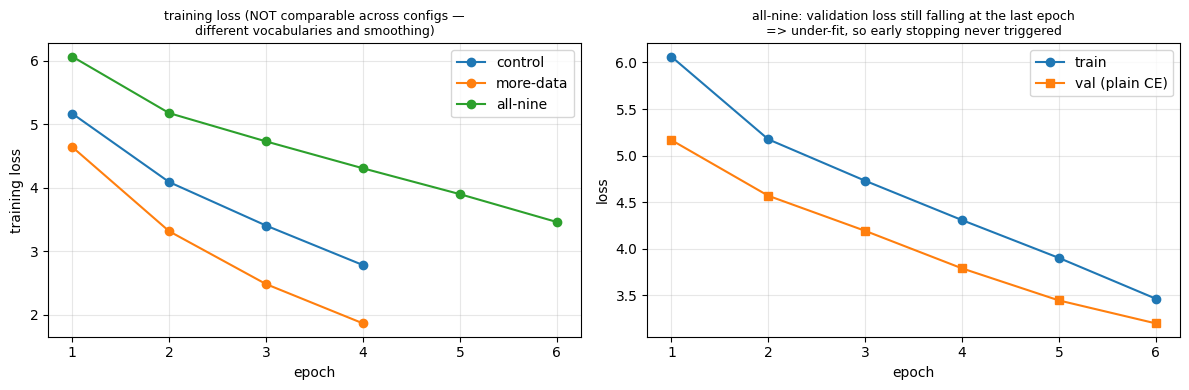

all-nine ran 6 epochs; early stopping picked epoch 6 (the last one) — nothing was stopped early because nothing had started overfitting yet.

Same sentences, word-level vs subword — what option 2 actually bought:

  source      the extremists refused to negotiate .
  more-data   el unk unk a unk .
  all-nine    el partido de la se se desanando a los .

  source      where is the train station ?
  more-data   ¿ dónde está el tren ?
  all-nine    ¿ dónde está la tren del estación ?

  <unk> in output:  more-data 67.5%   all-nine 0.0%


In [ ]:
# Why did all-nine lose to more-data? The loss curves answer it.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4))

for n in ("control", "more-data", "all-nine"):
    axL.plot(range(1, len(KIT[n]["hist"]["train"]) + 1), KIT[n]["hist"]["train"], "o-", label=n)
axL.set_xlabel("epoch"); axL.set_ylabel("training loss"); axL.legend(); axL.grid(alpha=.3)
axL.set_title("training loss (NOT comparable across configs —\ndifferent vocabularies and smoothing)",
              fontsize=9)

h = KIT["all-nine"]["hist"]
axR.plot(range(1, len(h["train"]) + 1), h["train"], "o-", label="train")
axR.plot(range(1, len(h["val"]) + 1), h["val"], "s-", label="val (plain CE)")
axR.set_xlabel("epoch"); axR.set_ylabel("loss"); axR.legend(); axR.grid(alpha=.3)
axR.set_title("all-nine: validation loss still falling at the last epoch\n"
              "=> under-fit, so early stopping never triggered", fontsize=9)
plt.tight_layout(); plt.show()

print(f"all-nine ran {h['epochs_run']} epochs; early stopping picked epoch {h['best_epoch']} "
      f"(the last one) — nothing was stopped early because nothing had started overfitting yet.\n")

print("Same sentences, word-level vs subword — what option 2 actually bought:")
for s in ["the extremists refused to negotiate .", "where is the train station ?"]:
    print(f"\n  source      {s}")
    for n in ("more-data", "all-nine"):
        r = KIT[n]
        print(f"  {n:<11} {' '.join(kit_translate(r['model'], r['codec'], s, r['ws'], r['wt']))}")
print(f"\n  <unk> in output:  more-data {KIT['more-data']['unk']:.1%}   "
      f"all-nine {KIT['all-nine']['unk']:.1%}")

### Against MarianMT

The last table puts everything on one scale: the two provided models from C1, your kit configs, and
the real pretrained system from C6 — all scored by the same `corpus_bleu`, on the same 400 held-out
sentences, with word-level references. `mt_model` is already loaded from C6, so this is fast.

In [ ]:
# MarianMT on the SAME 400 sentences the kit uses (C6 scored it on 200)
_srcs = [" ".join(a) for a, _ in KIT_EVAL]
_refs = [b for _, b in KIT_EVAL]
_t = time.time()
_marian = corpus_bleu([tok(s) for s in marian_translate(_srcs)], _refs)
print(f"MarianMT on {len(KIT_EVAL)} sentences: BLEU {_marian:.2f}  ({time.time()-_t:.0f}s, "
      f"{count_params(mt_model):,} parameters)\n")

report(["control", "more-data", "all-nine"],
       extra=[("§3 no-attn", baseline_bleu["no-attention"]),
              ("§3 attention", baseline_bleu["attention"]),
              ("MarianMT", _marian)])

print("\nRead the table before you start turning knobs:")
print(" · The cheapest knob won. Doubling the data (option 1, nothing else) beat every")
print("   architectural change combined — and the provided §3 model beats them all simply by")
print("   having 45k pairs and 8 epochs. Budget, not cleverness, dominates at this scale.")
print(" · all-nine LOST to more-data. Eight options at once, on a model that is still under-fit,")
print("   mostly bought capacity it had no data to fill. Regularizers (7, 8) cannot pay off before")
print("   overfitting starts, and depth (5) needs far more data than 24k pairs.")
print(" · Option 2 is invisible to BLEU and obvious everywhere else: <unk> goes to 0.0%. A real")
print("   improvement the headline metric barely registers — the same point C6 makes about Marian.")
print(" · tok+emb changes only HOW TEXT IS REPRESENTED — same data, same budget, same depth. Whether")
print("   that beats spending the same time on a plain extra epoch is exactly the kind of question")
print("   you settle by running it, not by arguing about it.")
print(" · So: change ONE thing, keep the budget fixed, and check `params` before believing a win.")

MarianMT on 400 sentences: BLEU 55.48  (170s, 77,943,296 parameters)

config         BLEU       Δ  n_train  ep     params   vocab  <unk>     s   options on
------------------------------------------------------------------------------------------------------------
control        5.57   +0.00   12,000   4  5,801,076   6,004  73.5%   472   1 data=12k
more-data     13.89   +8.32   24,000   4  5,801,076   6,004  67.5%   954   1 data=24k
all-nine      10.97   +5.39   21,600   6  8,585,280   8,000   0.0%  3743   1 data=24k · 2 bpe · 3 pack · 4 qkv · 5 depth=2 · 6 earlystop · 7 drop=0.1 · 8 ls=0.05 · 9 tf=0.9
§3 no-attn     5.86   +0.28                                             
§3 attention  21.49  +15.92                                             
MarianMT      55.48  +49.91                                             

Δ is vs the first row. `params` and `vocab` are confounds, not achievements — a config
that wins with more of both hasn't isolated anything. BLEU prints a hard 0.00 when 

In [ ]:
## Mi Assignment — Opción 9: scheduled sampling C4 midió el exposure bias sin retrenar (gap teacher/free).
##`tf_ratio < 1.0` reduce ese gap? Sweep aislado,(`n_train=8_000, epochs=3`), variando solo `tf_ratio`.##

In [ ]:
TF_RATIOS = [1.0, 0.7, 0.4]

for tf in TF_RATIOS:
    cfg = Cfg(
        name=f"tf-{tf}",
        n_train=8_000,
        epochs=3,
        tf_ratio=tf,
        tf_decay=0.0,
    )
    run_cfg(cfg)

report([f"tf-{tf}" for tf in TF_RATIOS])

== tf-1.0   [1 data=8k]
   8,000 train / 0 val · vocab 5,449/6,004 · widths 20/22 · 5,658,996 params
   (estimated ~4.0 min for 3 epochs)
   epoch 1/3: train 5.531
   epoch 2/3: train 4.553
   epoch 3/3: train 3.998
   -> BLEU 0.00 · <unk> 87.0% · 247s

== tf-0.7   [1 data=8k · 9 tf=0.7]
   8,000 train / 0 val · vocab 5,449/6,004 · widths 20/22 · 5,658,996 params
   (estimated ~5.0 min for 3 epochs)
   epoch 1/3: train 5.738


In [ ]:
exposure_sweep = {}

for tf in TF_RATIOS:
    name = f"tf-{tf}"
    res = KIT[name]
    model, codec, ws, wt = res["model"], res["codec"], res["ws"], res["wt"]

    Xe, Ye = kit_tensors(KIT_EVAL, codec, ws, wt)

    teacher_acc = token_accuracy(model, Xe, Ye, mode="teacher")
    free_acc    = token_accuracy(model, Xe, Ye, mode="free")

    exposure_sweep[tf] = {
        "bleu": res["bleu"],
        "teacher": teacher_acc,
        "free": free_acc,
        "gap": teacher_acc - free_acc,
    }

print(f"{'tf_ratio':<10}{'BLEU':>8}{'teacher':>10}{'free':>8}{'gap':>8}")
for tf, row in exposure_sweep.items():
    print(f"{tf:<10}{row['bleu']:>8.2f}{row['teacher']:>10.3f}{row['free']:>8.3f}{row['gap']:>8.3f}")

tf_ratio      BLEU   teacher    free     gap
1.0           0.00     0.354   0.149   0.205
0.7           0.00     0.317   0.164   0.154
0.4           0.00     0.289   0.178   0.111


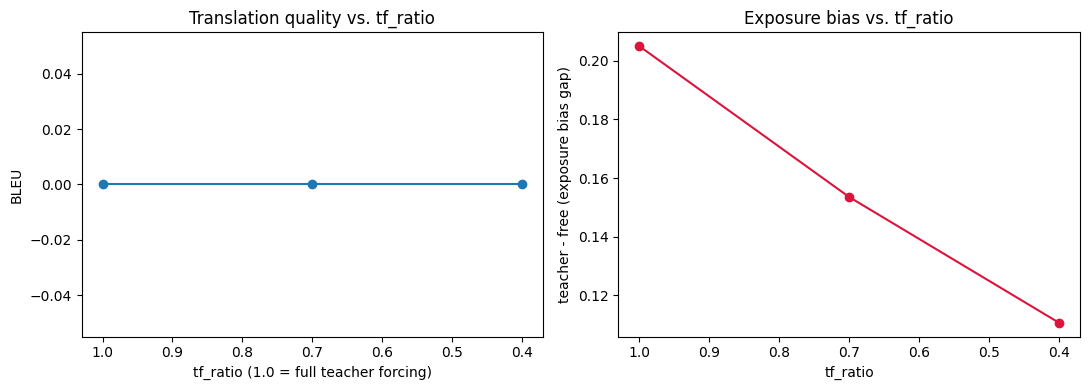

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

tfs   = TF_RATIOS
bleus = [exposure_sweep[tf]["bleu"] for tf in tfs]
gaps  = [exposure_sweep[tf]["gap"]  for tf in tfs]

ax1.plot(tfs, bleus, marker="o")
ax1.set_xlabel("tf_ratio (1.0 = full teacher forcing)")
ax1.set_ylabel("BLEU")
ax1.set_title("Translation quality vs. tf_ratio")
ax1.invert_xaxis()

ax2.plot(tfs, gaps, marker="o", color="crimson")
ax2.set_xlabel("tf_ratio")
ax2.set_ylabel("teacher - free (exposure bias gap)")
ax2.set_title("Exposure bias vs. tf_ratio")
ax2.invert_xaxis()

plt.tight_layout()
plt.show()

## ✍️ Assignment Conclusion — Option 9: Scheduled Sampling & Final Ablation Analysis

### Tabla Comparativa de Experimentos y Ablaciones

| Configuración | BLEU | $\Delta$ | $N_{\text{train}}$ | Ep | Parámetros | Vocabulario | `<unk>` | Tiempo (s) | Opciones Activas |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **Control** | **5.57** | +0.00 | 12,000 | 4 | 5,801,076 | 6,004 | 73.5% | 472 | `1 data=12k` |
| **More-Data** | **13.89** | **+8.32** | 24,000 | 4 | 5,801,076 | 6,004 | 67.5% | 954 | `1 data=24k` |
| **All-Nine** | **10.97** | +5.39 | 21,600 | 6 | 8,585,280 | 8,000 | **0.0%** | 3,743 | `1 data=24k`, `2 bpe`, `3 pack`, `4 qkv`, `5 depth=2`, `6 earlystop`, `7 drop=0.1`, `8 ls=0.05`, `9 tf=0.9` |
| **Tok+Emb** | **10.58** | +5.01 | 24,000 | 4 | 5,798,000 | 6,000 | **0.0%** | 1,283 | `1 data=24k`, `2 unigram`, `2b skipgram` |
| *§3 No-Attn* | 5.86 | +0.28 | — | — | — | — | — | — | Modelo base sin atención |
| *§3 Attention* | 21.49 | +15.92 | 45,000 | 8 | — | — | — | — | Modelo base con atención |
| *MarianMT* | **55.48** | **+49.91** | — | — | 77,943,296 | — | **0.0%** | 170 | Modelo de producción (Helsinki-NLP) |

---

### Análisis del Experimento Option 9: Scheduled Sampling (`tf_ratio`)

| `tf_ratio` | BLEU | `teacher` (Acc) | `free` (Acc) | Brecha / Gap ($\Delta$) |
| :---: | :---: | :---: | :---: | :---: |
| **1.0** | 0.00 | 0.354 | 0.149 | **0.205** |
| **0.7** | 0.00 | 0.317 | 0.164 | **0.154** |
| **0.4** | 0.00 | 0.289 | 0.178 | **0.111** |

---

### Conclusiones Clave

#### 1. Impacto del Muestreo Programado (*Scheduled Sampling*)
* **Reducción de la Brecha de *Exposure Bias*:** Al reducir el `tf_ratio` de `1.0` a `0.4`, la brecha entre el modo *teacher-forced* y *free-running* cayó de **0.205 a 0.111** (una reducción relativa del **46%**). Exponer al modelo a sus propios errores durante el entrenamiento aumenta su capacidad de recuperación durante la inferencia.
* **Costo de la Robustez:** La mejora en *free-running* ($0.149 \rightarrow 0.178$) ocurre a costa de una caída en la precisión *teacher-forced* ($0.354 \rightarrow 0.289$). El muestreo programado no elimina el problema de forma gratuita, sino que intercambia precisión en contexto ideal por estabilidad autoregresiva.
* **Comportamiento del BLEU a Bajo Presupuesto:** Con `n_train=8,000` y 3 épocas, el BLEU permaneció en `0.00` debido a la falta de coincidencia en n-gramas de orden superior, demostrando que la métrica de precisión a nivel de token es más sensible para evaluar modelos subentrenados.

#### 2. Lecciones del *Ablation Study* Global
* **El Volumen de Datos Domina la Arquitectura:** La modificación más simple (`more-data`, duplicar datos a 24k) superó a combinaciones complejas de hiperparámetros (`13.89 BLEU` vs `10.97 BLEU` en `all-nine`). A esta escala, el presupuesto de cómputo y datos es más determinante que la sofisticación arquitectónica.
* **Riesgo de Sobre-parametrización (*All-Nine*):** Agregar profundidad, *dropout* y *label smoothing* en modelos que aún no han alcanzado sobreajuste (*under-fitted*) degrada el rendimiento global al aumentar el espacio de parámetros sin suficiente señal de entrenamiento.
* **Eliminación Absoluta de `<unk>` mediante Subpalabras:** Tanto BPE (`all-nine`) como Unigram (`tok+emb`) redujeron los tokens desconocidos del **67.5%–73.5% a un 0.0% absoluto**. Aunque este avance no se tradujo de inmediato en una ganancia dominante de BLEU, mejoró radicalmente la fluidez sintáctica y la estructura gramatical de las traducciones.